## 💊**Personalized Treatment Supervised and Unsupervised ML Project**

#### **Context** 
Healthcare systems generate large volumes of patient data including demographics, medical history, lifestyle
behaviors, treatments, and clinical outcomes. Despite this availability, many treatment decisions remain
standardized. This project applies data analytics and machine learning to support personalized treatment planning.
#### **Problem Statement**
The goal is to analyze historical patient data and build predictive models that assist healthcare providers in
recommending personalized treatments, estimating recovery outcomes, and identifying relapse risk.

#### **Importing Libraries**

In [1953]:
# Importing necessary libraries

import pandas as pd         # for data filtering, data manipulation and data cleaning
import numpy as np             # for numerical operations
import matplotlib.pyplot as plt        # for creating visualizations from data
%matplotlib inline
import seaborn as sns                # for creating beautiful visualizations from data
from ydata_profiling import ProfileReport        # for automatically generating profile report of data
pd.set_option('display.max_columns', None)       # for displaying all columns

#### **Necessary Libraries**
- **Pandas** - Pandas is used for data analysis and handling tabular data like Excel.
It provides easy tools to load, clean, and explore data using DataFrames.
- **Numpy** - NumPy is a Python library used for fast mathematical and array operations.
It helps in working with large datasets using arrays, matrices, and functions.
- **Seaborn** - Seaborn is a Python library for making beautiful and simple statistical charts.
It is built on top of Matplotlib and works well with Pandas.
- **Matplotlib** - Matplotlib is used to create basic graphs like line, bar, and pie charts.
It helps in visualizing data in static and simple formats.
- **Plotly** - Plotly is a library for creating interactive and web-based charts.
It is used when you want zoomable and clickable graphs.
- **%matplotlib inline** - This is used in Jupyter Notebook to show plots right below your code cell.
It helps display Matplotlib charts inside the notebook.
warnings (import warnings)
- **import warnings** - import warnings is used to manage or ignore warning messages in Python.
It helps keep output clean and readable during code execution.
- **ydata_profiling** - ydata_profiling quickly creates an automatic EDA report from your data.
It gives summaries, graphs, and insights in one HTML file.

#### **Loading Dataset**

In [1957]:
# Loading file using read_csv() method of pandas

df = pd.read_csv("C:\\Users\\HP\\OneDrive\\Documents\\personalized_healthcare_patient_data.csv")

#### 🔎 **Dataset Overview**
The dataset consists of 9,000 synthetic yet realistic patient records. Each record represents a single treatment
episode and includes demographics, medical history, lifestyle factors, treatment details, and clinical outcomes.

In [1960]:
# Displaying first five rows from the DataFrame

df.head()

,Patient_ID,Age,Gender,BMI,Blood_Group,Region,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Diet_Type,Diabetes,Hypertension,Past_Diagnoses,Family_Medical_History,Allergies,Treatment_ID,Medication_Name,Dosage_mg,Treatment_Duration_Days,Adherence_Score,Side_Effects,Recovery_Time_Days,Improvement_Score,Relapse,Follow_Up_Results
0,300001,69,Male,26.6,O+,East,Non-Smoker,Heavy,Low,High Carb,No,No,NaN,Hypertension,NaN,TRT499298,Lifestyle Therapy,154,143,0.77,No,26,102.2,No,Stable
1,300002,32,Female,27.4,O+,Central,Current Smoker,Occasional,High,Vegetarian,No,No,NaN,NaN,NaN,TRT175205,Lifestyle Therapy,444,141,0.77,No,28,100.6,No,Stable
2,300003,78,Female,25.2,A+,East,Non-Smoker,Occasional,High,Vegetarian,No,No,NaN,Hypertension,Sulfa Drugs,TRT357334,General Medication,190,85,0.61,No,21,101.4,No,Improved
3,300004,38,Female,29.8,B-,South,Non-Smoker,NaN,Moderate,High Carb,No,No,NaN,Hypertension,NaN,TRT370670,Lifestyle Therapy,160,76,0.84,No,25,105.1,No,Improved
4,300005,41,Male,27.0,A+,West,Non-Smoker,Heavy,Moderate,Balanced,No,No,NaN,NaN,NaN,TRT540931,General Medication,248,161,0.89,No,24,107.4,No,Improved


In [1961]:
# Displaying last five rows from the DataFrame

df.tail()

,Patient_ID,Age,Gender,BMI,Blood_Group,Region,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Diet_Type,Diabetes,Hypertension,Past_Diagnoses,Family_Medical_History,Allergies,Treatment_ID,Medication_Name,Dosage_mg,Treatment_Duration_Days,Adherence_Score,Side_Effects,Recovery_Time_Days,Improvement_Score,Relapse,Follow_Up_Results
8995,308996,43,Male,29.8,B-,West,Current Smoker,NaN,Moderate,Balanced,Yes,No,NaN,Diabetes,NaN,TRT764912,Metformin,108,71,0.71,No,27,99.6,No,Improved
8996,308997,20,Female,33.2,AB+,South,Non-Smoker,Moderate,Moderate,Vegetarian,No,No,NaN,Cardiac Disease,NaN,TRT575853,Lifestyle Therapy,354,29,0.68,Yes,37,90.7,No,Improved
8997,308998,66,Female,30.5,A+,South,Former Smoker,Moderate,Moderate,Balanced,No,No,NaN,NaN,NaN,TRT362176,General Medication,6,160,0.61,No,29,95.0,No,Improved
8998,308999,34,Female,25.0,B+,East,Non-Smoker,NaN,Moderate,Balanced,No,No,NaN,Hypertension,Penicillin,TRT530458,General Medication,305,167,0.89,No,21,109.8,No,Improved
8999,309000,80,Female,30.1,A-,West,Non-Smoker,Moderate,Low,Balanced,Yes,Yes,Metabolic Disorder,NaN,NaN,TRT813482,Metformin,256,50,0.81,No,39,93.0,No,Stable


In [1962]:
# Displaying three sample records from the DataFrame

df.sample(3)

,Patient_ID,Age,Gender,BMI,Blood_Group,Region,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Diet_Type,Diabetes,Hypertension,Past_Diagnoses,Family_Medical_History,Allergies,Treatment_ID,Medication_Name,Dosage_mg,Treatment_Duration_Days,Adherence_Score,Side_Effects,Recovery_Time_Days,Improvement_Score,Relapse,Follow_Up_Results
2242,302243,24,Male,33.0,O+,East,Non-Smoker,NaN,Moderate,Vegetarian,No,No,NaN,Hypertension,NaN,TRT743787,Lifestyle Therapy,225,90,1.00,No,26,109.1,No,Stable
1604,301605,32,Male,20.8,O-,East,Non-Smoker,Occasional,High,High Fat,No,No,NaN,Hypertension,Sulfa Drugs,TRT574123,Lifestyle Therapy,90,169,0.78,No,18,108.9,No,Stable
6436,306437,42,Male,24.2,A+,North,Former Smoker,Moderate,Low,High Carb,No,No,NaN,Cardiac Disease,Penicillin,TRT262193,Lifestyle Therapy,332,61,1.00,No,30,105.9,No,Improved


In [1963]:
# Displaying all columns from the DataFrame

columns = df.columns.to_list()
print(list(columns))

['Patient_ID', 'Age', 'Gender', 'BMI', 'Blood_Group', 'Region', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Diet_Type', 'Diabetes', 'Hypertension', 'Past_Diagnoses', 'Family_Medical_History', 'Allergies', 'Treatment_ID', 'Medication_Name', 'Dosage_mg', 'Treatment_Duration_Days', 'Adherence_Score', 'Side_Effects', 'Recovery_Time_Days', 'Improvement_Score', 'Relapse', 'Follow_Up_Results']


#### **Discription of columns**
- **`Patient_ID`** - Unique identifier for each patient.
- **`Gender`** - Gender of the patient (Male, Female).
- **`Age`** - Age of the patient.  
- **`BMI`** - BMI (Body Mass Index) is a number that tells whether a person's weight is healthy for their height.
   - Below 18.5 means underweight
   - 18.5 - 24.9 means normal
   - 25 - 29.9 means overweight
   - 30 or more means obese
- **`Blood Group`** - Blood group of the patient ('O+', 'A+', 'B-', 'AB+', 'B+', 'A-', 'O-', 'AB-').
- **`Region`** - Region of the patient ('East', 'Central', 'South', 'West', 'North').
- **`Smoking Status`** - Smoking status of the patient ('Non-Smoker', 'Current Smoker', 'Former Smoker').
- **`Alcohol Consumption`** - Whether the patient consumes alcohol ('Heavy', 'Occasional', 'Unknown', 'Moderate').
- **`Physical Activity Level`** - How physically active the patient is ('Low', 'High', 'Moderate').
- **`Diet Type`** - Diet type of the patient ('High Carb', 'Vegetarian', 'Balanced', 'Keto', 'High Fat').
- **`Diabetes`** - Whether the patient has diabetes ('No', 'Yes').
- **`Hypertension`** - Whether the patient has hypertension ('No', 'Yes').
- **`Past Diagnoses`** - Diseases that the patient had in the past ('Unknown', 'Cardiac Risk', 'Obesity', 'Metabolic Disorder').
- **`Family Medical History`** - Medical history of the patient's family ('Hypertension', 'Unknown', 'Diabetes', 'Cardiac Disease').
- **`Allergies`** - Type of allergies the patient has ('Unknown', 'Sulfa Drugs', 'Food Allergy', 'Penicillin').
- **`Treatment ID`** - Unique identifier for each treatment and the treatment the patient is taking.
- **`Medication Name`** - Drug used for the patient's treatment ('Lifestyle Therapy', 'General Medication', 'Metformin', 'Insulin', 'ACE Inhibitor', 'Beta Blocker').
- **`Dosage mg`** - Amount of medicine given to the patient in milligrams.
- **`Treatment Duration Days`** - Duration of the treatment in days.
- **`Adherence Score`** - Measures how consistently a patient follows the prescribed treatment.
    - 1.0 means perfect adherence
    - 0.8 means mostly followed
    - 0.4 means poor adherence
- **`Side Effects`** - Whether the patient has side effects.
- **`Recovery Time Days`** - Number of days taken by a patient to recover after starting treatment.
- **`Improvement Score`** - How much the patient's condition improved after treatment.
- **`Relapse`** - Whether the patient became sick again after recovery ('No').
- **`Follow_Up_Results`** - Outcome after the treatment ('Stable', 'Improved').

In [1969]:
# Checking shape of the DataFrame

df.shape

(9000, 25)

**Dataset have 9000 observations with 25 columns.**

In [1972]:
# Generating profile report of the DataFrame

# Profile = ProfileReport(df)
# Profile

In [1974]:
# Here we are creating a copy of DataFrame which we will use for unsupervised learning technique

df1 = df.copy()
df2 = df.copy()

In [1976]:
# Checking summary of the DataFrame

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               9000 non-null   int64  
 1   Age                      9000 non-null   int64  
 2   Gender                   9000 non-null   object 
 3   BMI                      9000 non-null   float64
 4   Blood_Group              9000 non-null   object 
 5   Region                   9000 non-null   object 
 6   Smoking_Status           9000 non-null   object 
 7   Alcohol_Consumption      6034 non-null   object 
 8   Physical_Activity_Level  9000 non-null   object 
 9   Diet_Type                9000 non-null   object 
 10  Diabetes                 9000 non-null   object 
 11  Hypertension             9000 non-null   object 
 12  Past_Diagnoses           2063 non-null   object 
 13  Family_Medical_History   6480 non-null   object 
 14  Allergies               

#### **Handling Missing Values**

In [1979]:
# Checking missing values in every column of the DataFrame

df.isnull().sum()

Patient_ID                    0
Age                           0
Gender                        0
BMI                           0
Blood_Group                   0
Region                        0
Smoking_Status                0
Alcohol_Consumption        2966
Physical_Activity_Level       0
Diet_Type                     0
Diabetes                      0
Hypertension                  0
Past_Diagnoses             6937
Family_Medical_History     2520
Allergies                  6104
Treatment_ID                  0
Medication_Name               0
Dosage_mg                     0
Treatment_Duration_Days       0
Adherence_Score               0
Side_Effects                  0
Recovery_Time_Days            0
Improvement_Score             0
Relapse                       0
Follow_Up_Results             0
dtype: int64


**Dataset has 2966 missing values in Alcohol Consumption, 6937 in Past_Diagnoses, 2520 in Family_Medical_History and 6104 in Allergies column.**

In [1982]:
# Filling missing values in the columns Alcohol_Consumption, Past_Diagnosis, Allergies, Family_Medical_History
# Here we are filling missing values in all columns with keyword 'Unknown' because all the columns with missing values are categorical

df['Alcohol_Consumption'] = df['Alcohol_Consumption'].fillna('Unknown')
df['Past_Diagnoses'] = df['Past_Diagnoses'].fillna('Unknown')
df['Allergies'] = df['Allergies'].fillna('Unknown')
df['Family_Medical_History'] = df['Family_Medical_History'].fillna('Unknown')

In [1984]:
# Checking missing values after filling them

df.isnull().sum()

Patient_ID                 0
Age                        0
Gender                     0
BMI                        0
Blood_Group                0
Region                     0
Smoking_Status             0
Alcohol_Consumption        0
Physical_Activity_Level    0
Diet_Type                  0
Diabetes                   0
Hypertension               0
Past_Diagnoses             0
Family_Medical_History     0
Allergies                  0
Treatment_ID               0
Medication_Name            0
Dosage_mg                  0
Treatment_Duration_Days    0
Adherence_Score            0
Side_Effects               0
Recovery_Time_Days         0
Improvement_Score          0
Relapse                    0
Follow_Up_Results          0
dtype: int64

**`Now DataFrame has no missing values in any columns.`**

#### **Handling Duplicate Records**

In [1988]:
# Cheking count of duplicate records in the DataFrame

df.duplicated().sum()

0

**`DataFrame has no duplicate records.`**

In [1991]:
# Dropping columns which we will not need further for supervised machine learning techniques

df.drop('Patient_ID', axis = 1, inplace=True)
df.drop('Treatment_ID', axis = 1, inplace=True)
df.drop('Relapse', axis = 1, inplace = True)       # We cannot used it as target column because it has only one value('No')
df.drop('Blood_Group', axis = 1, inplace = True)     # Usually blood group has no correlation with any other column

#### **Feature Engineering**
Feature engineering means creating or changing columns (features) so the model can learn better.

In [1994]:
# Creating column 'Disease_Count'

df["Disease_Count"] = (
    (df["Diabetes"] == "Yes").astype(int) +
    (df["Hypertension"] == "Yes").astype(int)
)

In [1995]:
# Creating column Lifestyle

df["Lifestyle_Risk"] = (
    df["Smoking_Status"].map({
        "Current Smoker": 2,
        "Former Smoker": 1,
        "Non-Smoker": 0
    }).fillna(0)
    
    +
    
    df["Alcohol_Consumption"].map({
        "Heavy": 2,
        "Moderate": 1,
        "Occasional": 0.5,
        "Unknown": 0
    }).fillna(0)
    
    +
    
    df["Physical_Activity_Level"].map({
        "Low": 2,
        "Moderate": 1,
        "High": 0
    }).fillna(0)
)

In [1998]:
# Creating column Relapse_Probability

df["Relapse_Probability"] = (
    (1 - df["Adherence_Score"]/100) +
    (df["Disease_Count"]/df["Disease_Count"].max()) +
    (df["Lifestyle_Risk"]/df["Lifestyle_Risk"].max())
) / 3


In [2002]:
df.head()

,Age,Gender,BMI,Region,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Diet_Type,Diabetes,Hypertension,Past_Diagnoses,Family_Medical_History,Allergies,Medication_Name,Dosage_mg,Treatment_Duration_Days,Adherence_Score,Side_Effects,Recovery_Time_Days,Improvement_Score,Follow_Up_Results,Disease_Count,Lifestyle_Risk,Relapse_Probability
0,69,Male,26.6,East,Non-Smoker,Heavy,Low,High Carb,No,No,Unknown,Hypertension,Unknown,Lifestyle Therapy,154,143,0.77,No,26,102.2,Stable,0,4.0,0.552989
1,32,Female,27.4,Central,Current Smoker,Occasional,High,Vegetarian,No,No,Unknown,Unknown,Unknown,Lifestyle Therapy,444,141,0.77,No,28,100.6,Stable,0,2.5,0.469656
2,78,Female,25.2,East,Non-Smoker,Occasional,High,Vegetarian,No,No,Unknown,Hypertension,Sulfa Drugs,General Medication,190,85,0.61,No,21,101.4,Improved,0,0.5,0.359078
3,38,Female,29.8,South,Non-Smoker,Unknown,Moderate,High Carb,No,No,Unknown,Hypertension,Unknown,Lifestyle Therapy,160,76,0.84,No,25,105.1,Improved,0,1.0,0.386089
4,41,Male,27.0,West,Non-Smoker,Heavy,Moderate,Balanced,No,No,Unknown,Unknown,Unknown,General Medication,248,161,0.89,No,24,107.4,Improved,0,3.0,0.497033


In [2004]:
# Creating two lists - for categorical columns (cat_col) and numerical columns (num_col)

num_col = []
cat_col = []
for col in df.columns:
    if df[col].dtypes in ['int64','float64']:
        num_col.append(col)
    else:
        cat_col.append(col)
print('List with numerical columns :\n', num_col)
print('\nList with categorical columns :\n', cat_col)

List with numerical columns :
 ['Age', 'BMI', 'Dosage_mg', 'Treatment_Duration_Days', 'Adherence_Score', 'Recovery_Time_Days', 'Improvement_Score', 'Lifestyle_Risk', 'Relapse_Probability']

List with categorical columns :
 ['Gender', 'Region', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Diet_Type', 'Diabetes', 'Hypertension', 'Past_Diagnoses', 'Family_Medical_History', 'Allergies', 'Medication_Name', 'Side_Effects', 'Follow_Up_Results', 'Disease_Count']


In [2006]:
# Getting number of unique values and unique values of all categorical columns

for col in cat_col:
    n = df[col].nunique()
    unique_values = df[col].unique()
    print(f'{col} column has {n} unique values which are {unique_values}.\n')

Gender column has 2 unique values which are ['Male' 'Female'].

Region column has 5 unique values which are ['East' 'Central' 'South' 'West' 'North'].

Smoking_Status column has 3 unique values which are ['Non-Smoker' 'Current Smoker' 'Former Smoker'].

Alcohol_Consumption column has 4 unique values which are ['Heavy' 'Occasional' 'Unknown' 'Moderate'].

Physical_Activity_Level column has 3 unique values which are ['Low' 'High' 'Moderate'].

Diet_Type column has 5 unique values which are ['High Carb' 'Vegetarian' 'Balanced' 'Keto' 'High Fat'].

Diabetes column has 2 unique values which are ['No' 'Yes'].

Hypertension column has 2 unique values which are ['No' 'Yes'].

Past_Diagnoses column has 4 unique values which are ['Unknown' 'Cardiac Risk' 'Obesity' 'Metabolic Disorder'].

Family_Medical_History column has 4 unique values which are ['Hypertension' 'Unknown' 'Diabetes' 'Cardiac Disease'].

Allergies column has 4 unique values which are ['Unknown' 'Sulfa Drugs' 'Food Allergy' 'Penic

In [2008]:
# Checking value_counts for every categorical column

print('Value counts for every categorical columns -\n')
for col in cat_col:
    value_c = df[col].value_counts()
    print(f'{value_c}\n')

Value counts for every categorical columns -

Gender
Male      4689
Female    4311
Name: count, dtype: int64

Region
South      2639
North      2286
West       1669
East       1443
Central     963
Name: count, dtype: int64

Smoking_Status
Non-Smoker        5015
Former Smoker     2144
Current Smoker    1841
Name: count, dtype: int64

Alcohol_Consumption
Occasional    3246
Unknown       2966
Moderate      2017
Heavy          771
Name: count, dtype: int64

Physical_Activity_Level
Moderate    3889
Low         3250
High        1861
Name: count, dtype: int64

Diet_Type
Balanced      3810
High Carb     1902
High Fat      1488
Vegetarian    1048
Keto           752
Name: count, dtype: int64

Diabetes
No     7424
Yes    1576
Name: count, dtype: int64

Hypertension
No     7490
Yes    1510
Name: count, dtype: int64

Past_Diagnoses
Unknown               6937
Cardiac Risk           815
Metabolic Disorder     687
Obesity                561
Name: count, dtype: int64

Family_Medical_History
Unknown    

In [2010]:
# Getting a statistical summary of the numeric columns

df.describe()

,Age,BMI,Dosage_mg,Treatment_Duration_Days,Adherence_Score,Recovery_Time_Days,Improvement_Score,Disease_Count,Lifestyle_Risk,Relapse_Probability
count,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000,9000.000000
mean,51.051667,27.100878,242.000778,96.976778,0.781060,28.585667,100.459111,0.342889,2.377444,0.519958
std,19.309001,4.743312,146.870042,47.713735,0.124821,8.196552,7.931417,0.634757,1.249350,0.127165
min,18.000000,18.000000,5.000000,15.000000,0.300000,10.000000,68.800000,0.000000,0.000000,0.330000
25%,34.000000,23.700000,111.000000,56.000000,0.697500,23.000000,95.100000,0.000000,1.500000,0.441278
50%,51.000000,27.000000,239.000000,97.000000,0.780000,28.000000,100.700000,0.000000,2.500000,0.497133
75%,68.000000,30.400000,371.000000,139.000000,0.870000,34.000000,106.100000,1.000000,3.000000,0.580800
max,84.000000,45.000000,499.000000,179.000000,1.000000,56.000000,122.000000,2.000000,6.000000,0.998167


#### **Description of Numeric Columns**
##### **`Age`**
- Average age is 51 years.
- Most patients are between 34 and 68 years.
- Youngest patient is 18 years, oldest is 84 years.
##### **`BMI`**
- Average BMI is around 27, which is overweight.
- Most values lie between 23.7 and 30.4
- Minimum BMI is 18, maximum is 45.
##### **`Dosage mg`**
- Average dosage is about 242 mg.
- Common dosage range is 111 mg to 371 mg.
- Dosage varies a lot (from 5 mg to 499 mg)
##### **`Treatment Duration`**
- Average treatment duration is 97 days.
- Most patients are treated between 56 and 139 days.
- Minimum is 15 days, maximum is 179 days.
##### **`Adherence Score`**
- Average adherence score is 0.78
- Most patients have adherence between 0.70 and 0.87
- Minimum is 0.30, maximum is 1
##### **`Recovery Time Days`**
- Average recovery time is about 29 days.
- Most recover between 23 and 34 days.
- Fastest recovery is 10 days, slowest is 56 days.
##### **`Improvement Score`**
- Average improvement score is around 100.
- Most values lie between 95 and 106.

In [2013]:
# Getting summary of numeric columns

df.describe(include = [object])

,Gender,Region,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Diet_Type,Diabetes,Hypertension,Past_Diagnoses,Family_Medical_History,Allergies,Medication_Name,Side_Effects,Follow_Up_Results
count,9000,9000,9000,9000,9000,9000,9000,9000,9000,9000,9000,9000,9000,9000
unique,2,5,3,4,3,5,2,2,4,4,4,6,2,2
top,Male,South,Non-Smoker,Occasional,Moderate,Balanced,No,No,Unknown,Unknown,Unknown,Lifestyle Therapy,No,Improved
freq,4689,2639,5015,3246,3889,3810,7424,7490,6937,2520,6104,4210,7632,5275


#### **Description of Categoric Columns**
##### **`Gender`**
- Gender column has 2 unique values (Male, Female).
- Top gender category is Male with a frequency of 4689.

##### **`Blood_Group`**
- Blood group column has 8 unique values ('O+', 'A+', 'B-', 'AB+', 'B+', 'A-', 'O-', 'AB-').
- Top blood group category is O+ with a frequency of 2661.

##### **`Region`**
- Region column has 5 unique values ('East', 'Central', 'South', 'West', 'North').
- Top region category is O+ with a frequency of 2639.

##### **`Smoking_Status`**
- Smoking_Status column has 5 unique values ('Non-Smoker', 'Current Smoker', 'Former Smoker').
- Top smoking status category is Non-Smoker with a frequency of 5015.

##### **`Alcohol_Consumption`**
- Alcohol consumption column has 4 unique values ('Heavy', 'Occasional', 'Unknown', 'Moderate').
- Top alcohol consumption category is Occasional with a frequency of 3246.

##### **`Physical_Activity_Level`**
- Physical_Activity_Level column has 3 unique values ('Low', 'High', 'Moderate').
- Top physical activity level category is Moderate with a frequency of 3889.

##### **`Diet_Type`**
- Diet_Type column has 5 unique values ('High Carb', 'Vegetarian', 'Balanced', 'Keto', 'High Fat').
- Top diet type category is Balanced with a frequency of 3810.

##### **`Diabetes`**
- Diabetes column has 2 unique values ('Yes', 'No').
- Top diabetes category is 'No' with a frequency of 7424.

##### **`Hypertension`**
- Hypertension column has 2 unique values ('Yes', 'No').
- Top hypertension category is Moderate with a frequency of 7490.

##### **`Past_Diagnoses`**
- Past_Diagnoses column has 5 unique values ('Unknown', 'Cardiac Risk', 'Obesity', 'Metabolic Disorder').
- Top past diagnoses category is 'Unknown' with a frequency of 6937.

##### **`Family_Medical_History`**
- Family_Medical_History column has 4 unique values ('Hypertension', 'Unknown', 'Diabetes', 'Cardiac Disease').
- Top family medical history category is 'Unknown' with a frequency of 2520.

##### **`Allergies`**
- Allergies column has 4 unique values ('Unknown', 'Sulfa Drugs', 'Food Allergy', 'Penicillin').
- Top allergies category is 'Unknown' with a frequency of 6104.

##### **`Medication_Name`**
- Medication_Name column has 6 unique values ('Lifestyle Therapy', 'General Medication', 'Metformin', 'Insulin', 'ACE Inhibitor', 'Beta Blocker').
- Top medication name category is 'Lifestyle Therapy' with a frequency of 4210.

##### **`Side_Effects`**
- Side_Effects column has 2 unique values ('Yes', 'No').
- Top side effects category is 'No' with a frequency of 7632.

##### **`Relapse`**
- Relapse column has only 1 unique value ('No').

##### **`Follow_Up_Results`**
- Follow_Up_Results column has 2 unique values ('Stable', 'Improved').
- Top follow-up results category is 'Improved' with a frequency of 5275.

In [2016]:
# Checking skewness in the numeric column of the DataFrame

for col in num_col:
    skew = df[col].skew()
    if skew == 0:
        distribution = 'normally distributed'
    elif skew > 0.5:
        distribution = 'right skewed'
    elif skew < -0.5:
        distribution = 'left skewed'
    else:
        distribution = 'approximate normally distributed'
    print(f'Skewness of column {col} is {round(skew, 3)} and it is {distribution}.\n')

Skewness of column Age is 0.002 and it is approximate normally distributed.

Skewness of column BMI is 0.156 and it is approximate normally distributed.

Skewness of column Dosage_mg is 0.063 and it is approximate normally distributed.

Skewness of column Treatment_Duration_Days is -0.006 and it is approximate normally distributed.

Skewness of column Adherence_Score is -0.259 and it is approximate normally distributed.

Skewness of column Recovery_Time_Days is 0.305 and it is approximate normally distributed.

Skewness of column Improvement_Score is -0.211 and it is approximate normally distributed.

Skewness of column Lifestyle_Risk is 0.261 and it is approximate normally distributed.

Skewness of column Relapse_Probability is 0.999 and it is right skewed.



#### **Handling Outliers**

In [2019]:
# Checking outliers in numeric columns using IQR 

for col in num_col:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1
    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'Column {col} has {len(outliers)} outliers.')

Column Age has 0 outliers.
Column BMI has 24 outliers.
Column Dosage_mg has 0 outliers.
Column Treatment_Duration_Days has 0 outliers.
Column Adherence_Score has 42 outliers.
Column Recovery_Time_Days has 63 outliers.
Column Improvement_Score has 35 outliers.
Column Lifestyle_Risk has 66 outliers.
Column Relapse_Probability has 411 outliers.


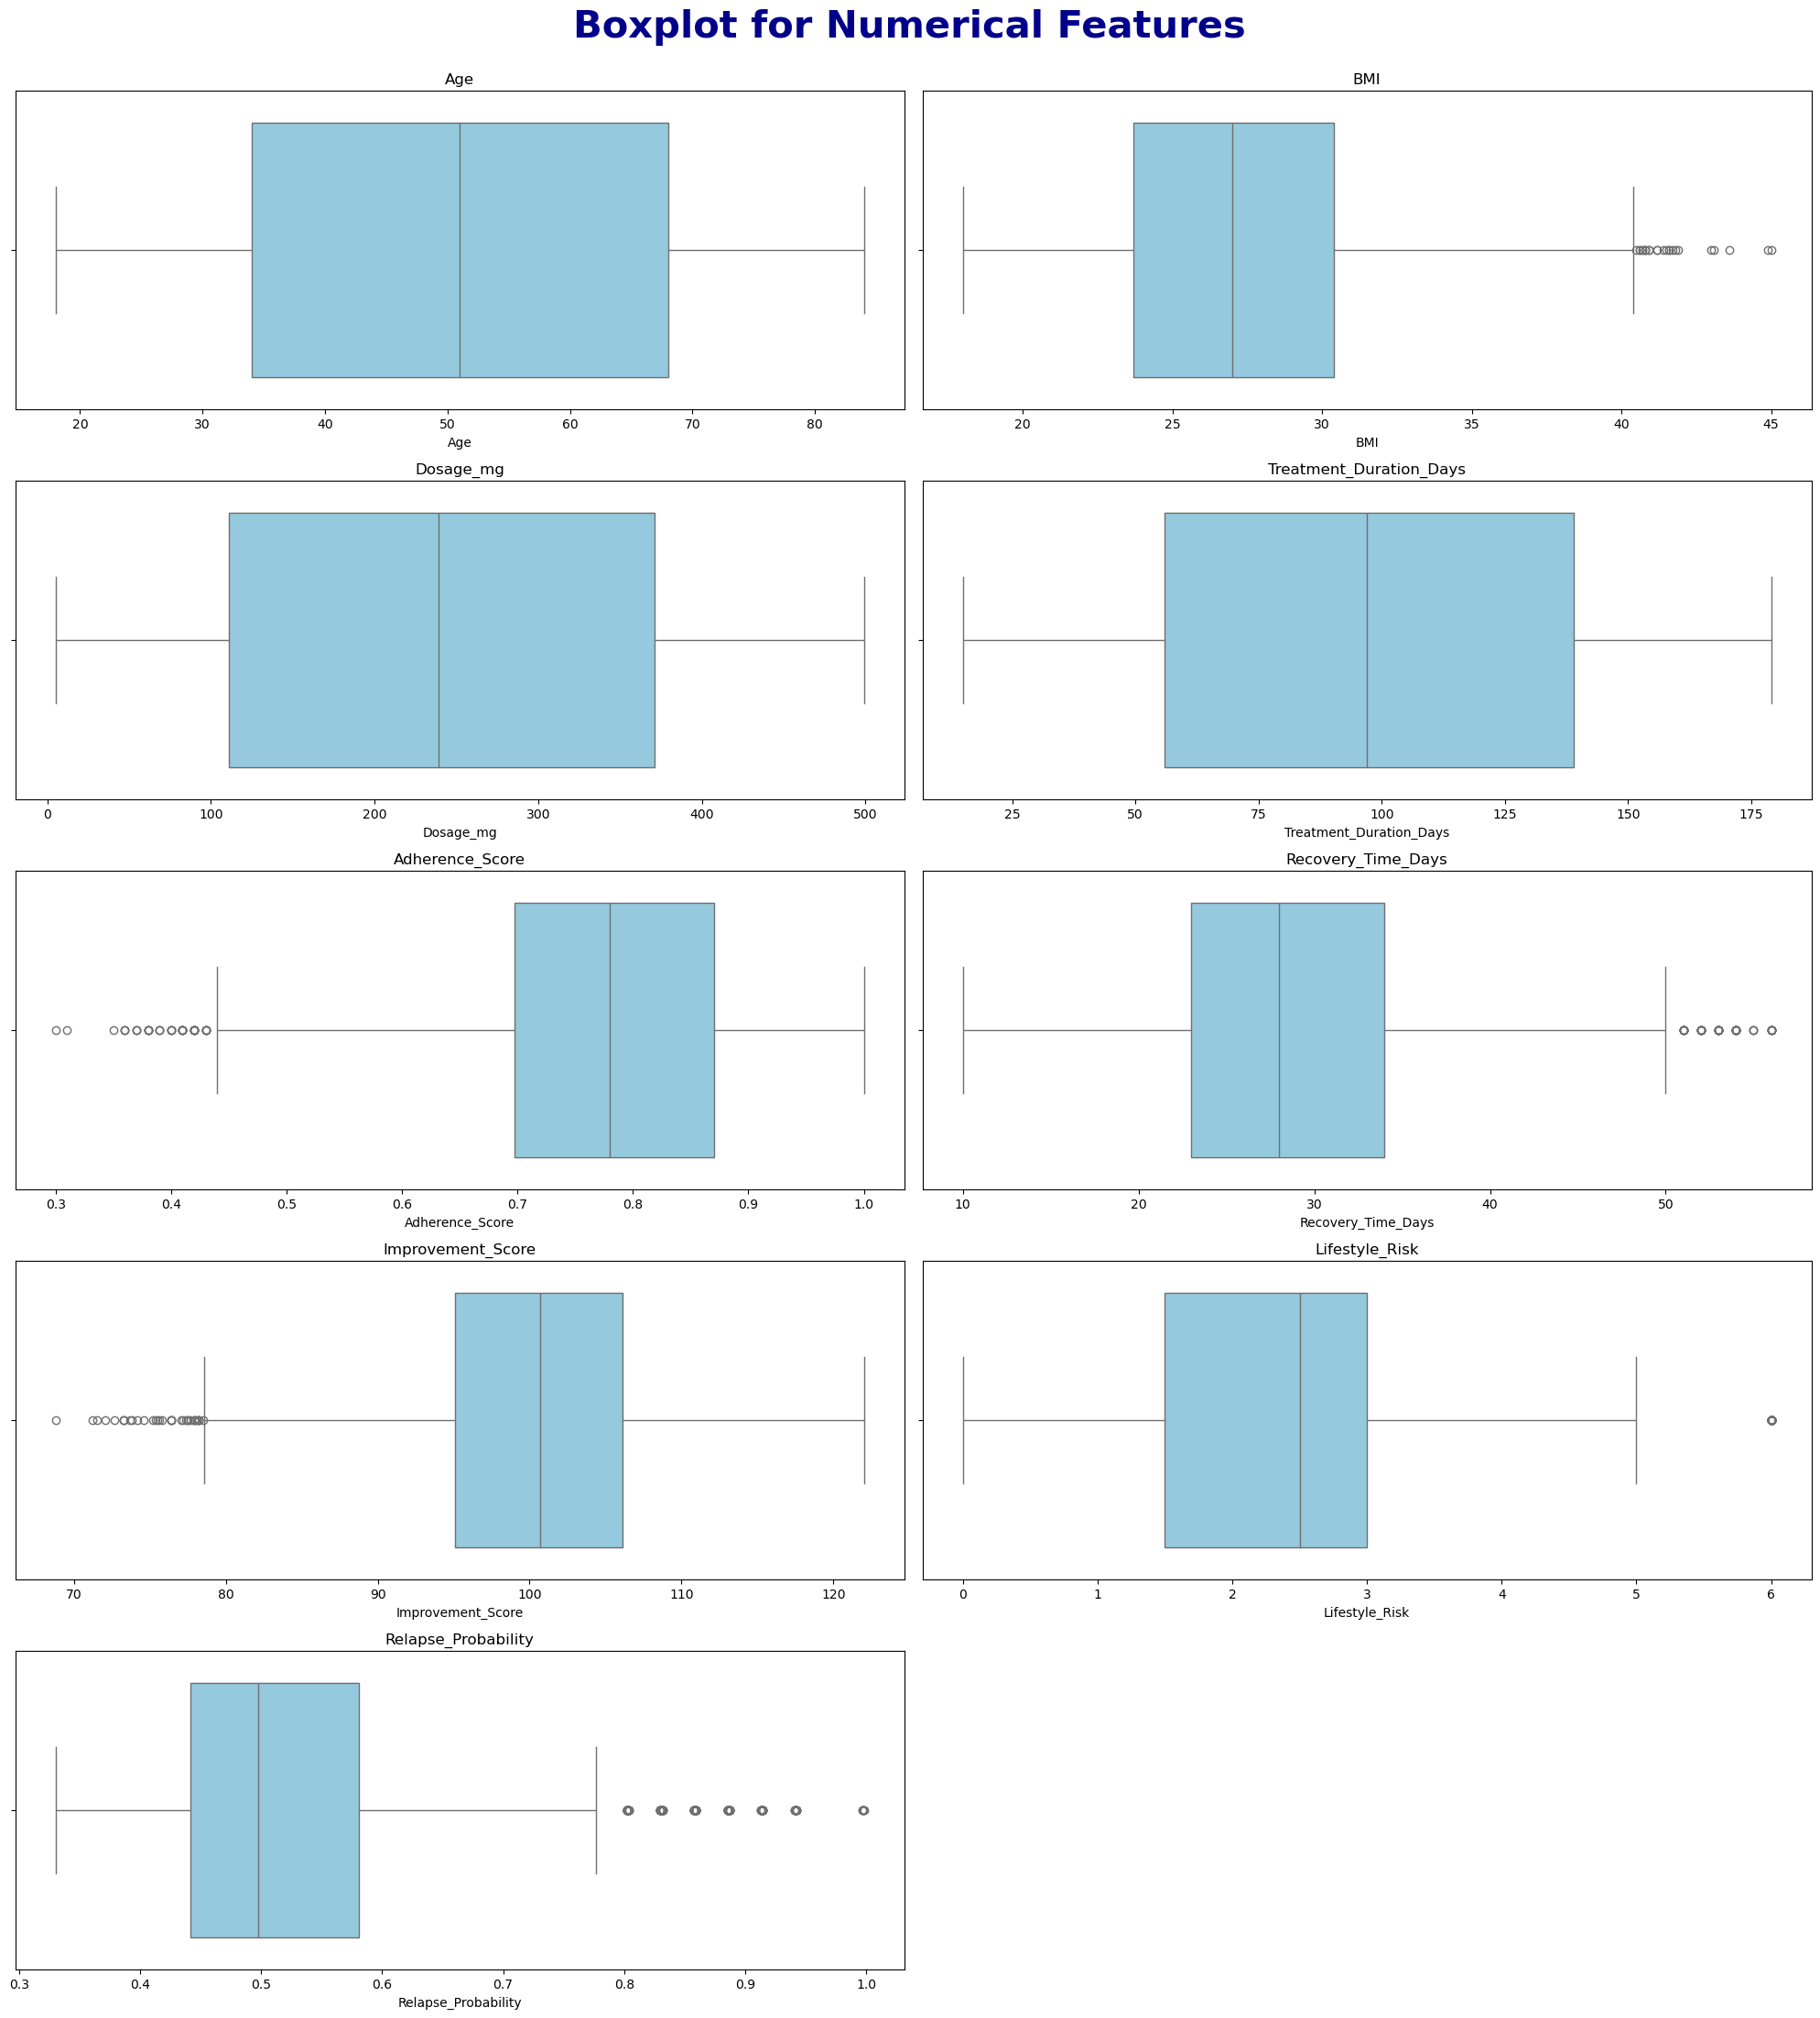

In [2021]:
# Plotting boxplot to detect outliers 

# Create a figure with 4 rows and 2 columns of subplot
# Axes is individual plot where we plot boxplot here
fig, axes = plt.subplots(5, 2 , figsize=(20, 22))

# Flatten the 2D array of axes into a 1D array so we can loop easily
axes = axes.flatten()

# Iterate throught each column with position which helps to pick up correct subplot
for i, col in enumerate(num_col):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)

# Adjusting the layout so that the plots don't overlap with each other
fig.delaxes(axes[-1])
plt.suptitle('Boxplot for Numerical Features', fontsize=30, fontweight='bold', color='darkblue', y = 1)
plt.tight_layout()
plt.show()

In [2022]:
# Now we are using capping method to handle remaining outliers
# Capping is a way to handle outliers by replacing extreme values with a maximum or minimum limit to reduce their effect on analysis.

for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

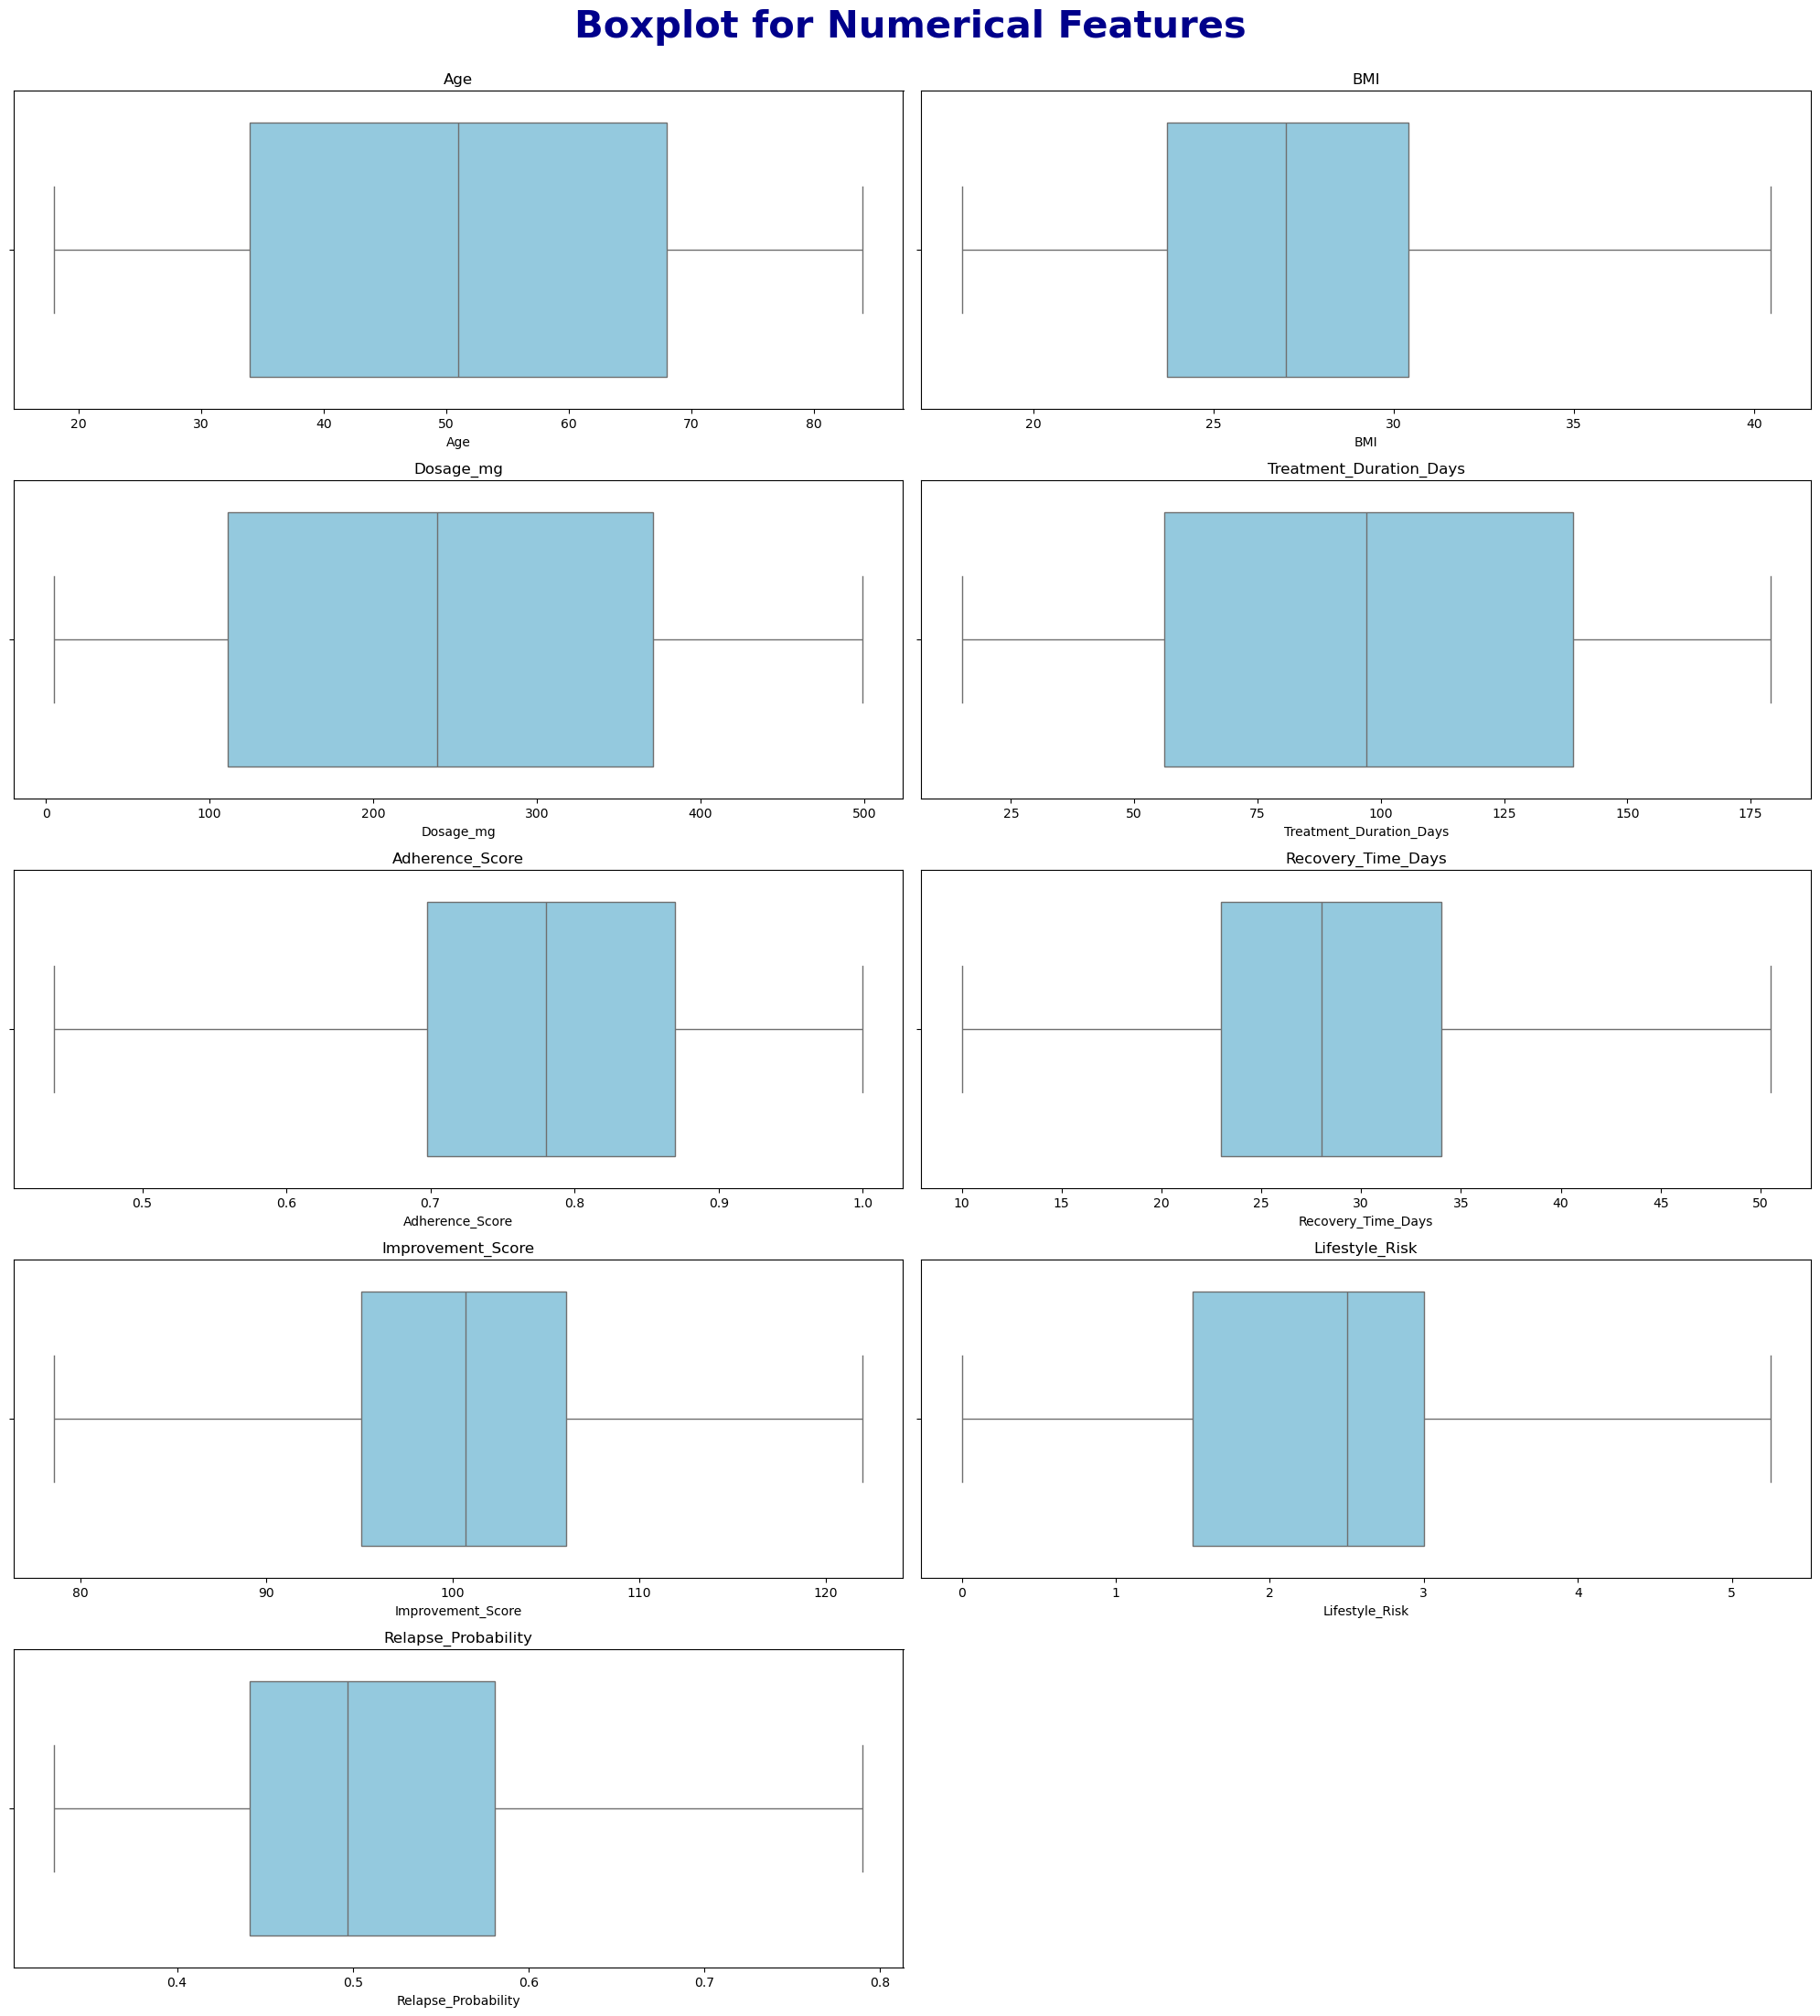

In [2023]:
# Plotting boxplot to check outliers are completely handled or not

# Create a figure with 7 rows and 2 columns of subplot
# Axes is individual plot where we plot boxplot here
fig, axes = plt.subplots(5, 2 , figsize=(20, 22))

# Flatten the 2D array of axes into a 1D array so we can loop easily
axes = axes.flatten()

# Iterate throught each column with position which helps to pick up correct subplot
for i, col in enumerate(num_col):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(col)

# Adjusting the layout so that the plots don't overlap with each other
fig.delaxes(axes[-1])
plt.suptitle('Boxplot for Numerical Features', fontsize=30, fontweight='bold', color='darkblue', y = 1)
plt.tight_layout()
plt.show()

In [2024]:
# Checking outliers in numerical columns using IQR 

for col in num_col:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    IQR = q3 - q1
    lower = q1 - 1.5 * IQR
    upper = q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'Column {col} has {len(outliers)} outliers.')

Column Age has 0 outliers.
Column BMI has 0 outliers.
Column Dosage_mg has 0 outliers.
Column Treatment_Duration_Days has 0 outliers.
Column Adherence_Score has 0 outliers.
Column Recovery_Time_Days has 0 outliers.
Column Improvement_Score has 0 outliers.
Column Lifestyle_Risk has 0 outliers.
Column Relapse_Probability has 0 outliers.


**`DataFrame has no outliers in any column.`**

In [2027]:
# Generating profile report after cleaning the dataset

# Profile = ProfileReport(df)
# Profile

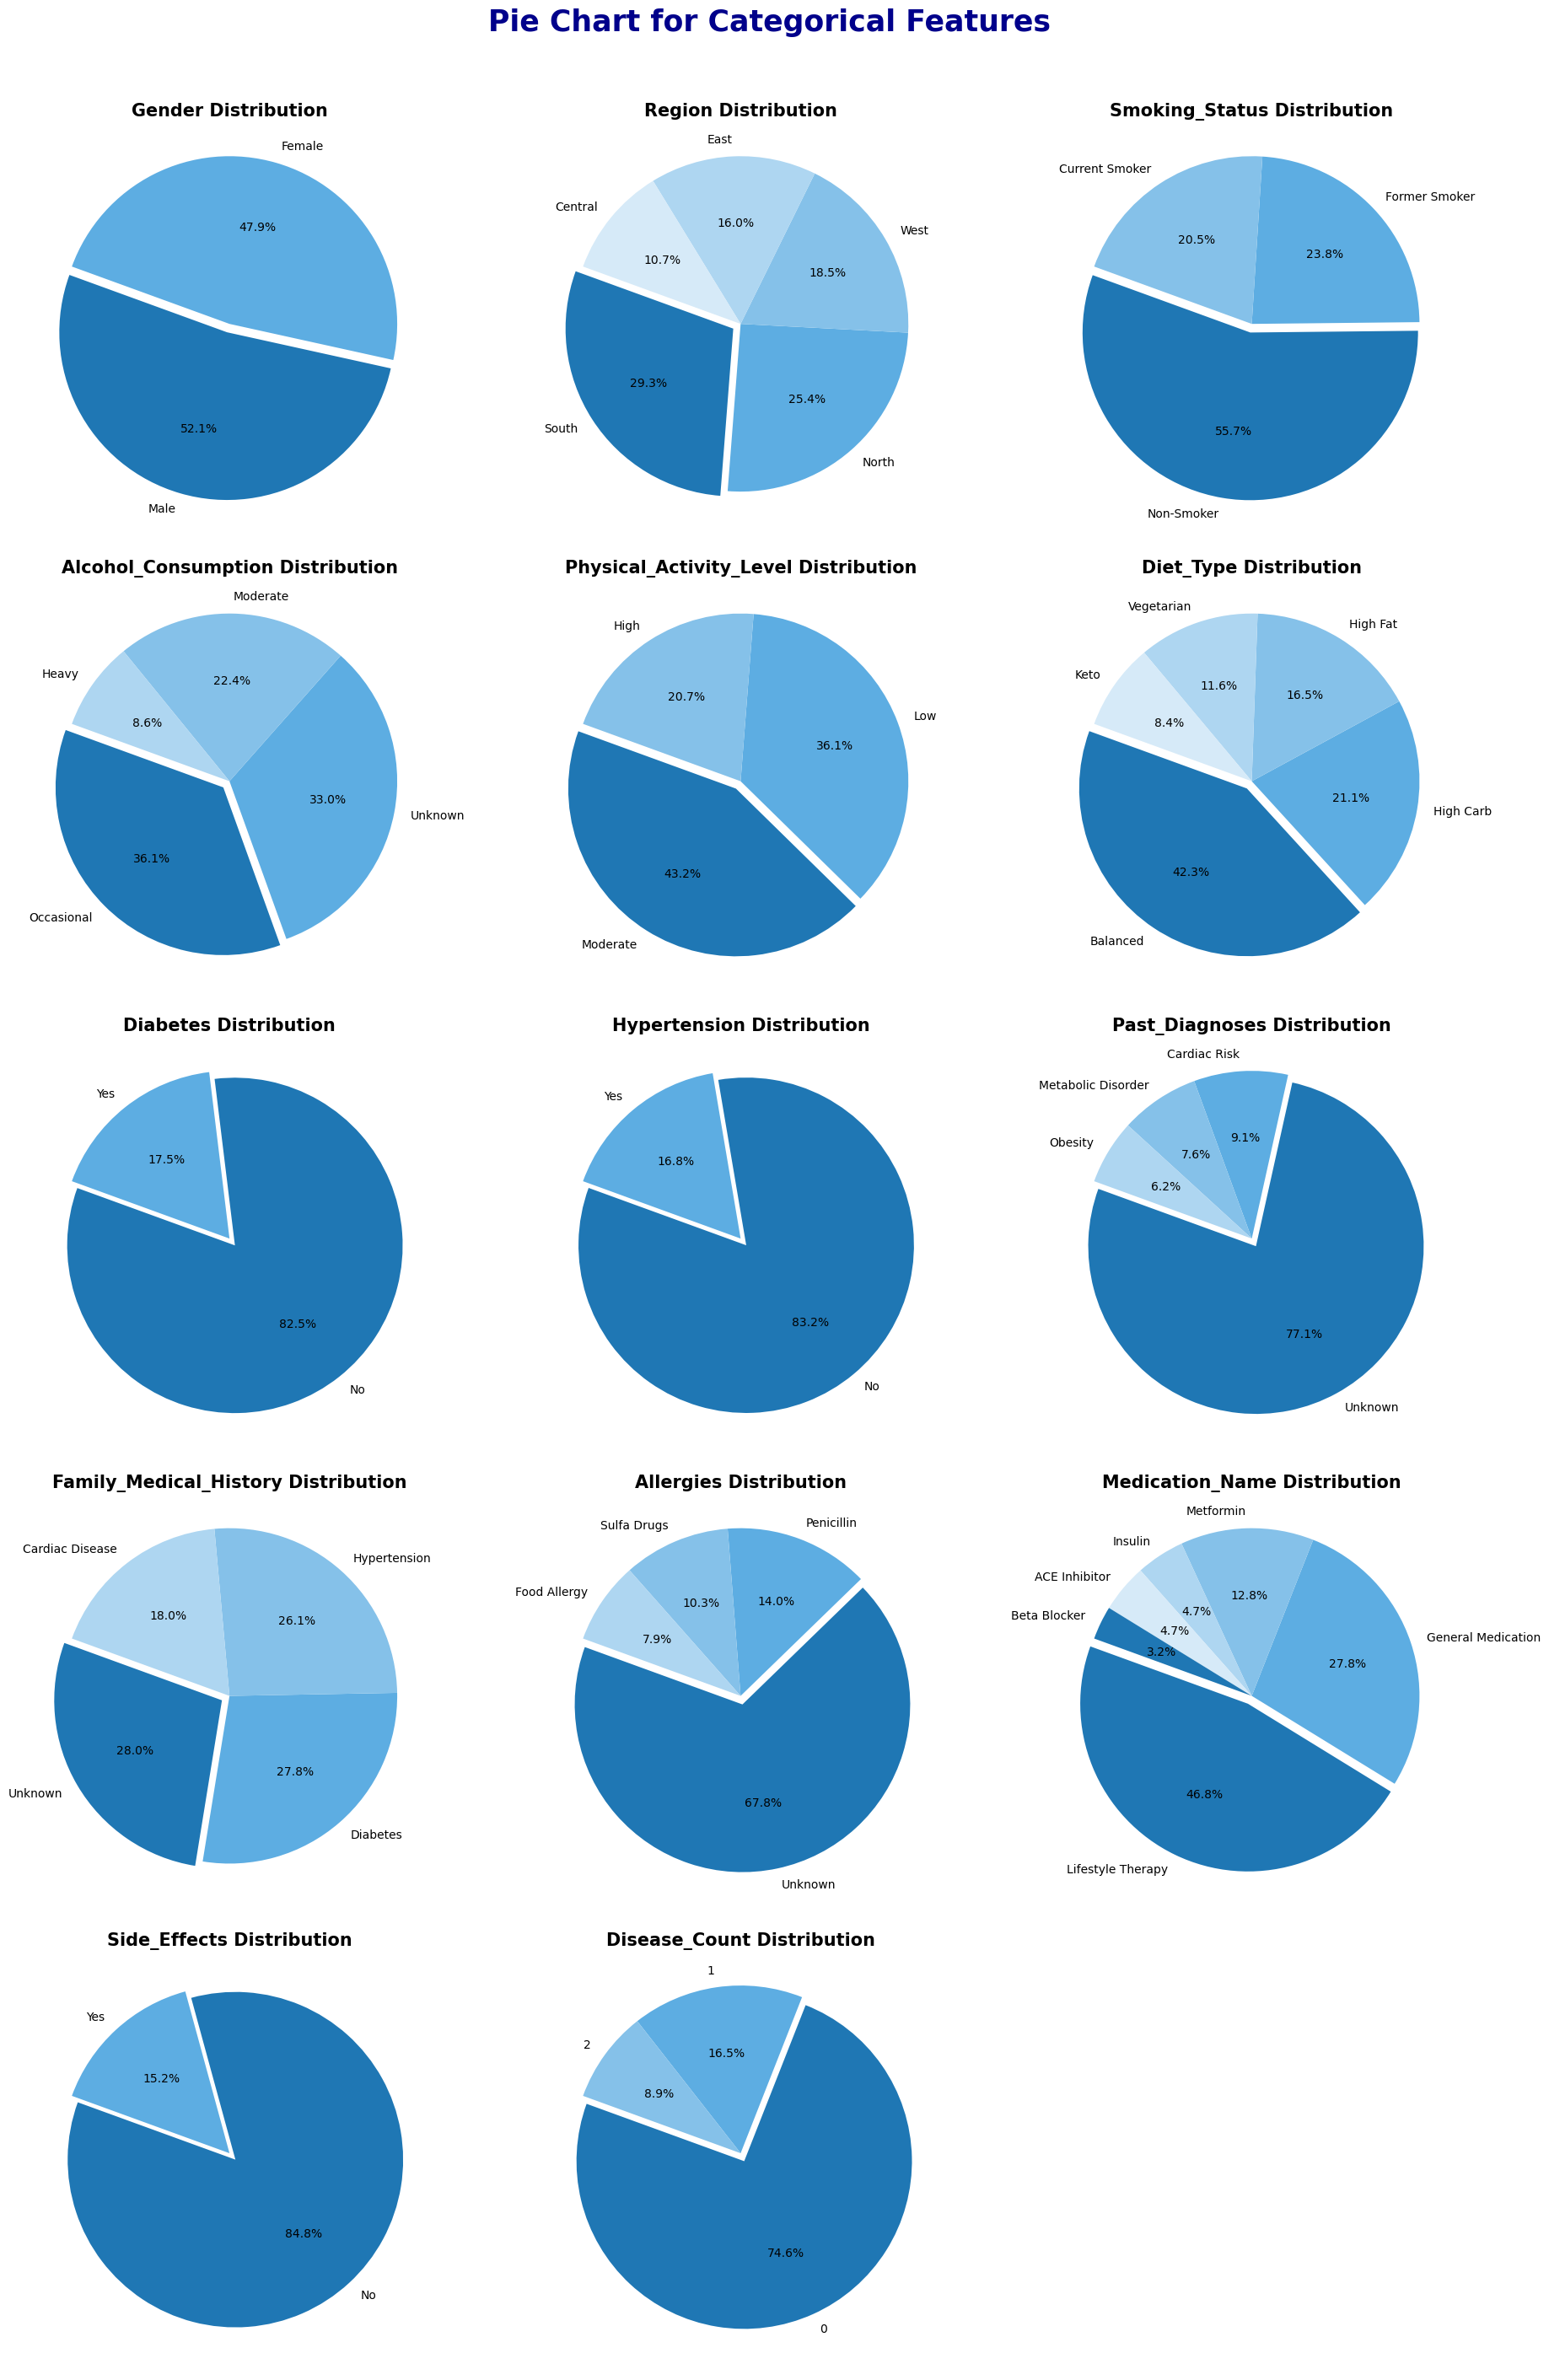

In [2029]:
# Displaying pie chart to get distribution of categorical columns

# Create subplots: 4 rows, 2 columns
fig, axes = plt.subplots(5,3, figsize=(19, 28))  

# Flatten the 2D axes array to 1D for easy iteration
axes = axes.flatten()

# List of cat_col
cat_cols = ['Gender', 'Region', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Diet_Type', 'Diabetes', 'Hypertension', 'Past_Diagnoses', 'Family_Medical_History', 'Allergies', 'Medication_Name', 'Side_Effects','Disease_Count']

# Defining the color palette
blue_colors = ['#1f77b4', '#5dade2', '#85c1e9', '#aed6f1', '#d6eaf8']

for i, col in enumerate(cat_cols):
    data = df[col].value_counts().values
    labels = df[col].value_counts().index
    explode = [0.05 if v == max(data) else 0 for v in data]
    axes[i].pie(data, labels=labels, autopct='%1.1f%%', explode=explode, colors=blue_colors, startangle = 160, radius=0.96)
    axes[i].set_title(f'{col} Distribution', fontweight='bold', fontsize=15, y=0.96)
plt.suptitle('Pie Chart for Categorical Features', fontsize=25, fontweight='bold', color='darkblue', y = 1.015)
plt.tight_layout()
fig.delaxes(axes[-1])
plt.show()

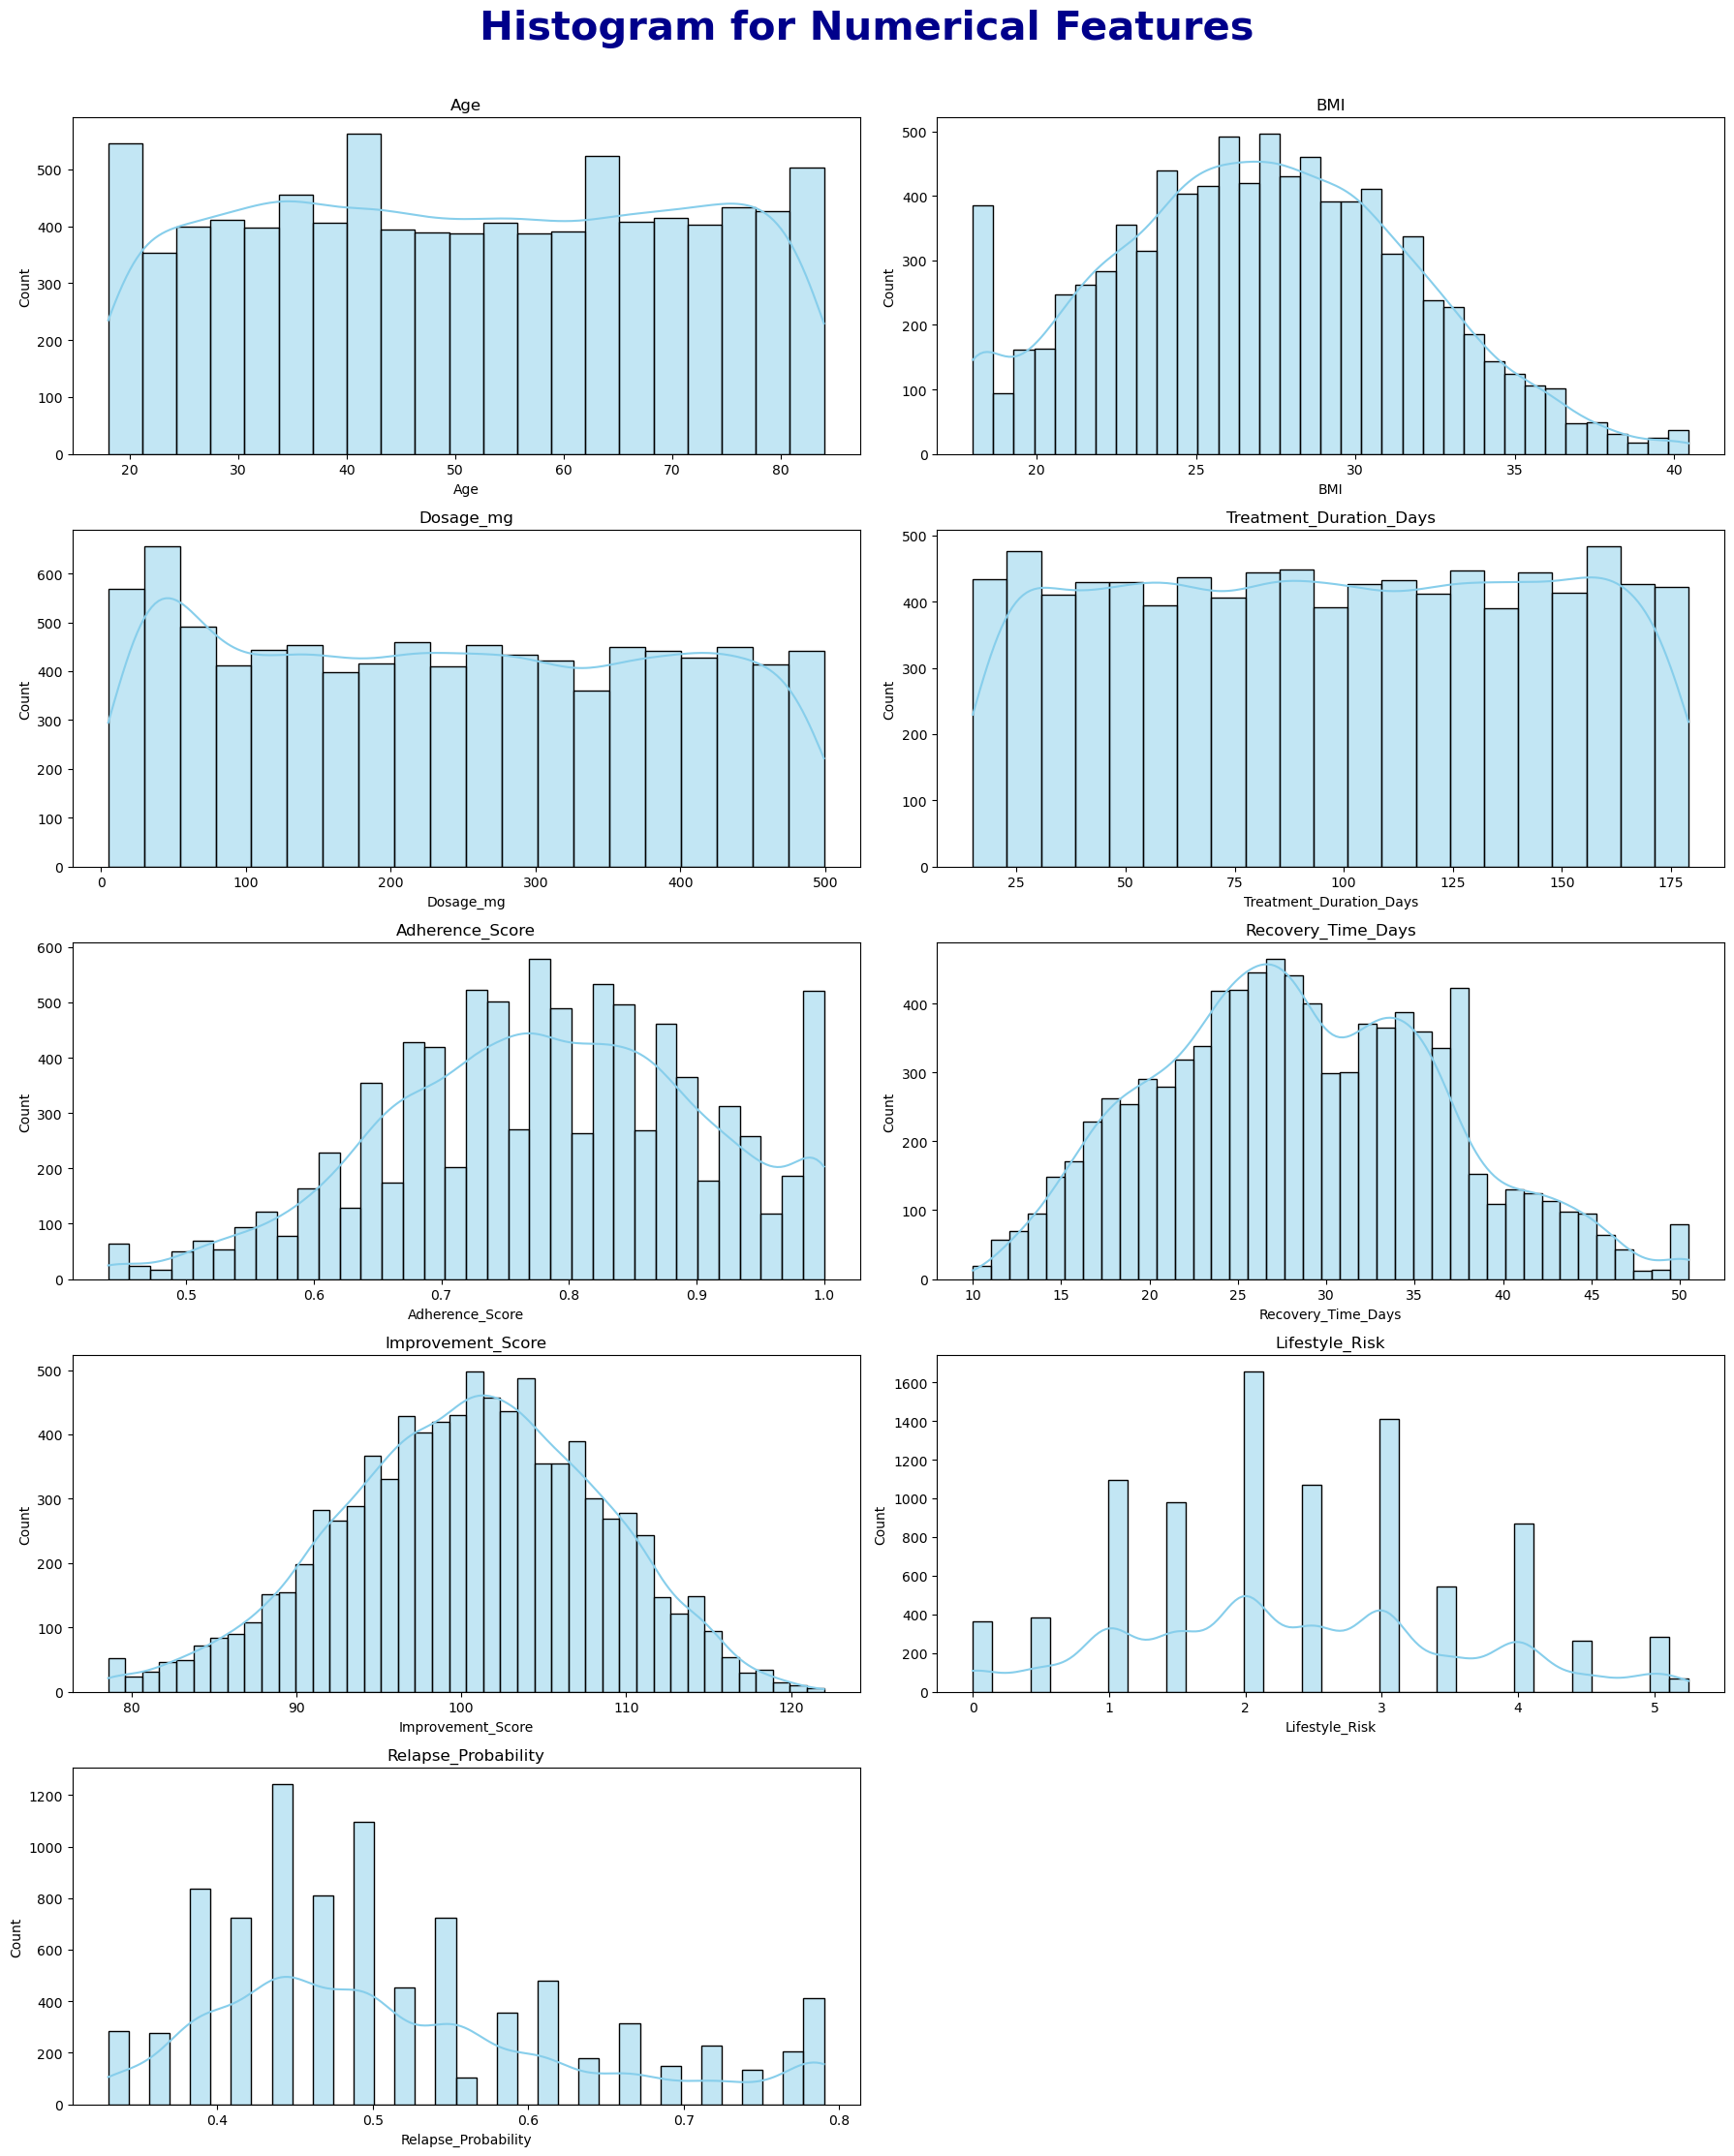

In [2030]:
# Plotting histogram to check distribution of numerical columns

# Create a figure with 7 rows and 2 columns of subplot
fig, axes = plt.subplots(5, 2, figsize=(18, 22))
axes = axes.flatten()
for i, col in enumerate(num_col):
    sns.histplot(x=df[col], ax=axes[i], color='skyblue', kde=True)
    axes[i].set_title(col)

# Adjusting the layout so that the plots don't overlap with each other
fig.delaxes(axes[-1])
plt.suptitle('Histogram for Numerical Features', fontsize=30, fontweight='bold', color='darkblue', y = 1.01)
plt.tight_layout()
plt.show()

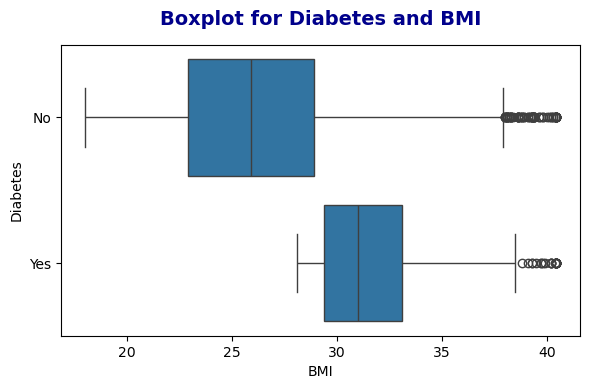

In [2031]:
# Relationship between BMI and Diabetes

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['BMI'], y=df['Diabetes'])
plt.title('Boxplot for Diabetes and BMI', y=1.04, fontweight='bold', fontsize=14, color='darkblue')
plt.tight_layout()
plt.show()

#### **Relationship between BMI and Diabetes**
1. People with Diabetes have higher BMI.
2. This means diabetic people generally have higher BMI.
3. Non-diabetic patients generally have lower BMI.
4. Both groups have some very high BMI values.
5. BMI varies more for non-diabetic patients.

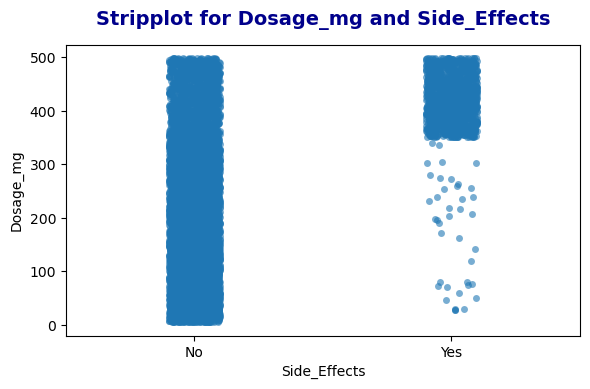

In [2033]:
# Relationship between side effects and dosage mg

plt.figure(figsize=(6, 4))
sns.stripplot(x='Side_Effects',y='Dosage_mg', data=df, jitter=True, alpha=0.6)
plt.title('Stripplot for Dosage_mg and Side_Effects', y=1.04, fontweight='bold', fontsize=14, color='darkblue')
plt.tight_layout()
plt.show()

#### **Relationship between Dosage_mg and Side_Effects**
1. Generally patient have side effects when dosage_mg are higher.
2. Some patients have side effects with lower dosage.
3. Patients with no side effects have variation in dosage_mg.
4. Many patients do not have side effects, even with higher doses.
5. As dosage_mg increases, the chance of side effect increases.

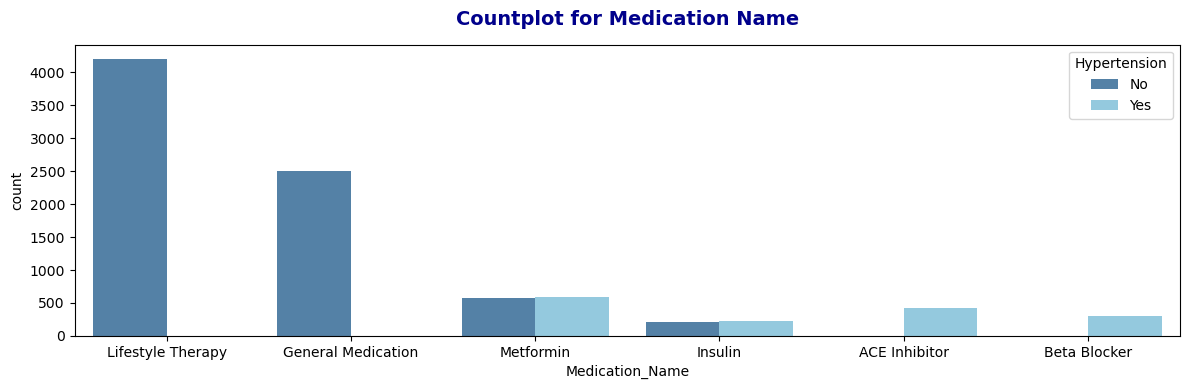

In [2038]:
# Countplot for Medication_Name

plt.figure(figsize=(12,4))
sns.countplot(x='Medication_Name', hue='Hypertension',data=df, palette=['steelblue','skyblue'])
plt.title('Countplot for Medication Name', y=1.04, fontweight='bold', fontsize=14, color='darkblue')
plt.tight_layout()
plt.show()

In [2039]:
# Relationship between Medication and Hypertension using crosstab

pd.crosstab(df['Hypertension'], df['Medication_Name'])

Medication_Name,ACE Inhibitor,Beta Blocker,General Medication,Insulin,Lifestyle Therapy,Metformin
Hypertension,,,,,,
No,0,0,2503,201,4210,576
Yes,420,291,0,219,0,580


#### **Relationship between Medication and Hypertension**
##### **`Lifestyle Therapy`**
- Lifestyle therapy has the highest number of patients, which is 4210.
- It is mostly used by patients who do not have hypertension.

##### **`General Medication`**
- It has the second highest number of patients, which is 2503.
- It is used by patients who do not have hypertension.

##### **`Metformin`**
- It is used by both types of patients.
- 580 patients have hypertension, and 576 patients do not have hypertension.

##### **`Insulin`**
- It is used by both types of patients.
- 219 patients have hypertension, and 201 patients do not have hypertension.

##### **`Beta Blocker`**
- It is used only by patients with hypertension.
- Number of patients is 291.

##### **`ACI Inhibitor`**
- It is used by patients with hypertension.
- Number of patients is 420.


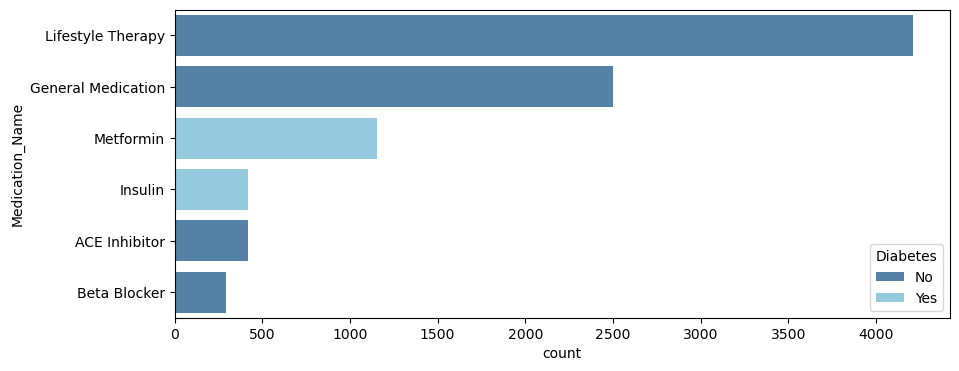

In [2041]:
# Relationship between Medication and Diabetes

plt.figure(figsize=(10,4))
sns.countplot(y='Medication_Name', hue='Diabetes',data=df, palette=['steelblue','skyblue'])
plt.show()

In [2043]:
# Relationship between Medication and Diabetes using crosstab

pd.crosstab(df['Diabetes'], df['Medication_Name'])

Medication_Name,ACE Inhibitor,Beta Blocker,General Medication,Insulin,Lifestyle Therapy,Metformin
Diabetes,,,,,,
No,420,291,2503,0,4210,0
Yes,0,0,0,420,0,1156


#### **Relationship between Medication and Diabetes**
##### **`Lifestyle Therapy`**
- Lifestyle therapy has the highest number of patients, which is 4210.
- It is mostly used by non-diabetic patients.

##### **`General Medication`**
- It has the second highest number of patients, which is 2503.
- It is used by non-diabetic patients.

##### **`Metformin`**
- It is used by diabetic patients.
- Number of patients using this is 1156.

##### **`Insulin`**
- It is used by diabetic patients.
- Number of patients using this is 420.

##### **`Beta Blocker`**
- It is used by non-diabetic patients.
- Number of patients using this is 291.

##### **`ACI Inhibitor`**
- It is used by non-diabetic patients.
- Number of patients using this is 420.


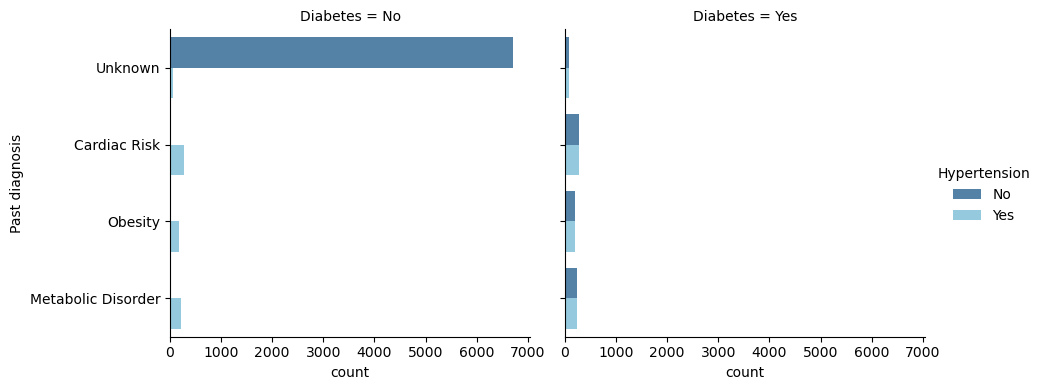

In [2045]:
# Relationship between past diagnosis, diabetes and hypertension

g = sns.catplot(data=df, y='Past_Diagnoses', hue='Hypertension', col='Diabetes', kind='count', height=4, aspect=1.2, palette=['steelblue','skyblue'])
g.set_axis_labels('count','Past diagnosis')
g.set_titles('Diabetes = {col_name}')
plt.show()

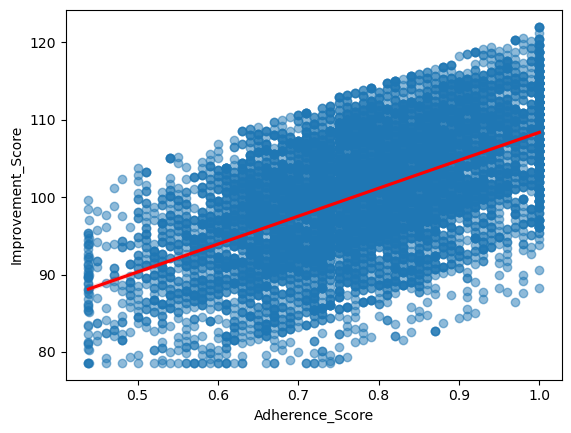

In [2046]:
# Relationship between Adherence Score and Improvement Score

sns.regplot(x='Adherence_Score', y='Improvement_Score', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'Red'})
plt.show()

#### **Relationship between Adherence Score and Improvement Days**
1. There is a positive linear relationship between adherence score and improvement days.
2. Patients who follow the treatment better show continuous improvement.
3. As the adherence score increases, improvement days also increase.

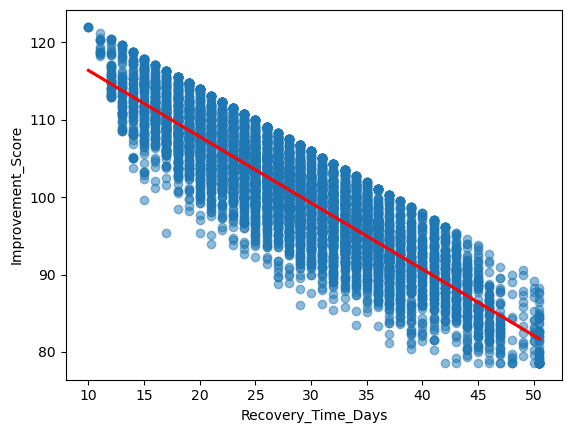

In [2048]:
# Relationship between Recovery Time Days and Improvement Days

sns.regplot(x='Recovery_Time_Days', y='Improvement_Score', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'Red'})
plt.show()

#### **Relationship between Recovery Time Days and Improvement Days**
1. When recovery time increases, improvement days decreases.
2. Their is negative relationship between improvement days andd recovery time days.
3. It indicates that patients shows improvement earlier tend to recover faster.

C:\Users\HP\AppData\Local\Temp\ipykernel_7100\2708604402.py:4: UserWarning: 
The palette list has fewer values (4) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(x='Past_Diagnoses', hue='Medication_Name',data=df , palette=['steelblue', 'skyblue', 'dodgerblue', 'lightskyblue'])


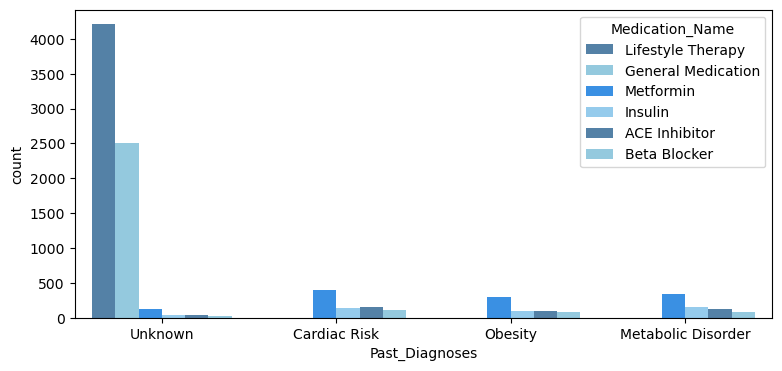

In [2050]:
# Relationship between Medication and Past_Diagnoses

plt.figure(figsize=(9,4))
sns.countplot(x='Past_Diagnoses', hue='Medication_Name',data=df , palette=['steelblue', 'skyblue', 'dodgerblue', 'lightskyblue'])
# plt.xticks(rotation = 45)
plt.show()

#### **Label Encoding**

In [2052]:
# Applying nominal label encoding 

from sklearn.preprocessing import LabelEncoder   # importing label encoder from sklearn.preprocessing
le = LabelEncoder()                          # initializing label encoder
nominal_cols = ['Gender', 'Region', 'Diet_Type','Diabetes','Hypertension', 'Past_Diagnoses', 'Family_Medical_History', 'Allergies', 'Medication_Name', 'Side_Effects', 'Follow_Up_Results']
for col in nominal_cols:
    df[col] = le.fit_transform(df[col])

In [2053]:
# Applying ordinal encoding on categoric columns where order matters

from sklearn.preprocessing import OrdinalEncoder    # importing ordinal encoder from sklearn.preprocessing

alcohol_category = [['Unknown', 'Occasional', 'Moderate', 'Heavy']]
smoke_category = [['Non-Smoker', 'Former Smoker', 'Current Smoker']]
activity_category = [['Low', 'Moderate', 'High']]

oe = OrdinalEncoder(categories=alcohol_category)       # initializing ordinal encoder
df['Alcohol_Consumption'] = oe.fit_transform(df[['Alcohol_Consumption']])     # applying ordinal encoder to Alcohol_Consumption column
oe = OrdinalEncoder(categories=smoke_category)         # initializing ordinal encoder
df['Smoking_Status'] = oe.fit_transform(df[['Smoking_Status']])               # applying ordinal encoder to Smoking_Status column
oe = OrdinalEncoder(categories=activity_category)      # initializing ordinal encoder
df['Physical_Activity_Level'] = oe.fit_transform(df[['Physical_Activity_Level']])   # applying ordinal encoder to Physical_Activity_Level column

In [2054]:
# Displaying first five rows

df.head()

,Age,Gender,BMI,Region,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Diet_Type,Diabetes,Hypertension,Past_Diagnoses,Family_Medical_History,Allergies,Medication_Name,Dosage_mg,Treatment_Duration_Days,Adherence_Score,Side_Effects,Recovery_Time_Days,Improvement_Score,Follow_Up_Results,Disease_Count,Lifestyle_Risk,Relapse_Probability
0,69,1,26.6,1,0.0,3.0,0.0,1,0,0,3,2,3,4,154,143,0.77,0,26.0,102.2,1,0,4.0,0.552989
1,32,0,27.4,0,2.0,1.0,2.0,4,0,0,3,3,3,4,444,141,0.77,0,28.0,100.6,1,0,2.5,0.469656
2,78,0,25.2,1,0.0,1.0,2.0,4,0,0,3,2,2,2,190,85,0.61,0,21.0,101.4,0,0,0.5,0.359078
3,38,0,29.8,3,0.0,0.0,1.0,1,0,0,3,2,3,4,160,76,0.84,0,25.0,105.1,0,0,1.0,0.386089
4,41,1,27.0,4,0.0,3.0,1.0,0,0,0,3,3,3,2,248,161,0.89,0,24.0,107.4,0,0,3.0,0.497033


#### **Correlation Heatmap**

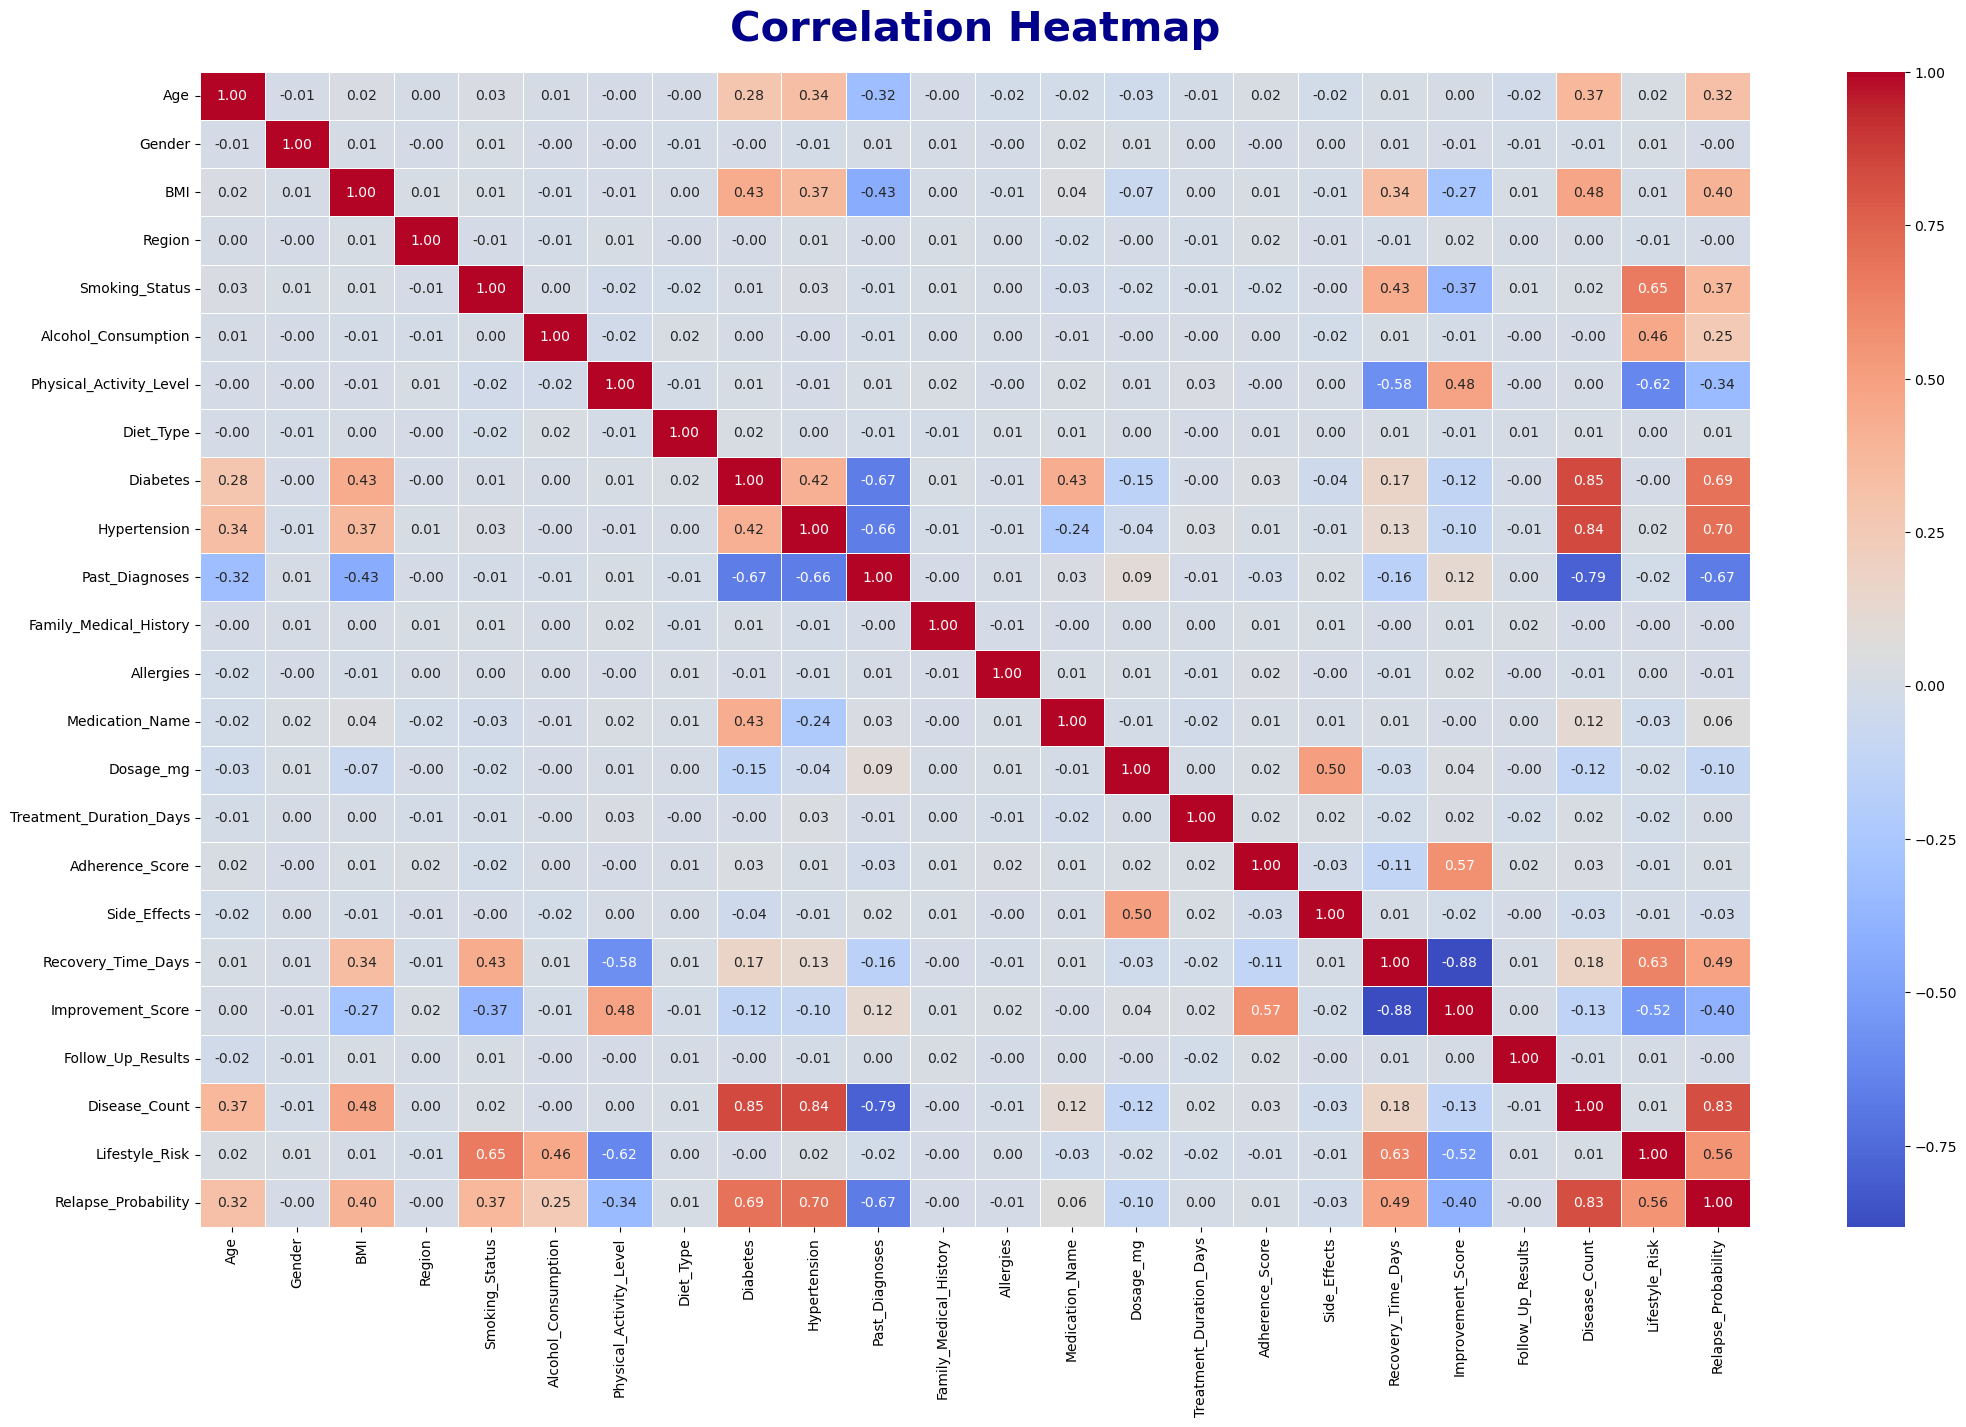

In [2056]:
# Creating heatmap to check correlation

plt.figure(figsize=(25, 15))
sns.heatmap(df.corr(), annot=True, fmt='.2f', linewidths=0.5, cmap='coolwarm')
plt.title('Correlation Heatmap', fontsize=30, fontweight='bold', y=1.02, color='darkblue')
plt.show()

#### **Top Positive Correlations**
- Adherence Score and Improvement Score (0.56)
- Dosage mg and Side Effects (0.50)
- Improvement Score and Physical Activity Level (0.48)
- Medication Name and Diabetes (0.48)
- Diabetes and BMI (0.43)
- Diabetes and Hypertension (0.42)
- Recovery Time Days and Smoking Status (0.40)
- BMI and Hypertension (0.36)
- Age and Hypertension (0.34)
- Age and Diabetes (0.28)
- Recovery Time Days and BMI (0.31)

#### **Top Negative Correlations**
- Improvement Score and Recovery Time Days (-0.87)
- Past Diagnosis and Diabetes (-0.67)
- Past Diagnosis and Hypertension (-0.66)
- Recovery Time Days and Physical Activity Level (-0.59)
- BMI and Past Diagnosis (-0.43)

In [2059]:
# Dropping column Family_Medical_History, Region, Diet_type, Allergies, Follow_Up_Results, Treatment_Duration_Days

df.drop('Family_Medical_History', axis = 1, inplace=True)
df.drop('Region', axis = 1, inplace=True)
df.drop('Diet_Type', axis = 1, inplace = True)      
df.drop('Allergies', axis = 1, inplace = True) 
df.drop('Follow_Up_Results', axis = 1, inplace = True) 
df.drop('Treatment_Duration_Days', axis = 1, inplace = True) 
df.drop('Gender', axis = 1, inplace = True) 

#### **Train Test Split For Predicting Recovery Time Days**

In [2108]:
df.columns

Index(['Age', 'BMI', 'Smoking_Status', 'Alcohol_Consumption',
       'Physical_Activity_Level', 'Diabetes', 'Hypertension', 'Past_Diagnoses',
       'Medication_Name', 'Dosage_mg', 'Adherence_Score', 'Side_Effects',
       'Recovery_Time_Days', 'Improvement_Score', 'Disease_Count',
       'Lifestyle_Risk', 'Relapse_Probability'],
      dtype='object')

In [2140]:
from sklearn.model_selection import train_test_split  # import train_test_split to split the dataset into testing and training datasets

# Defining X and y

X = df[['Age', 'BMI', 'Smoking_Status', 'Alcohol_Consumption',
       'Physical_Activity_Level', 'Diabetes', 'Hypertension', 'Past_Diagnoses',
       'Medication_Name', 'Dosage_mg', 'Adherence_Score', 'Side_Effects',
       'Improvement_Score', 'Disease_Count',
       'Lifestyle_Risk']]   # all columns except the target column
y = df["Relapse_Probability"]               # only target columns

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### **Feature Scaling**

In [2143]:
df.head()

,Age,BMI,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Diabetes,Hypertension,Past_Diagnoses,Medication_Name,Dosage_mg,Adherence_Score,Side_Effects,Recovery_Time_Days,Improvement_Score,Disease_Count,Lifestyle_Risk,Relapse_Probability
0,0.929584,-0.105128,0.0,3.0,0.0,0,0,3,4,-0.599208,-0.090649,0,-0.315278,0.219020,0,4.0,0.552989
1,-0.986728,0.063907,2.0,1.0,2.0,0,0,3,4,1.375437,-0.090649,0,-0.069591,0.016354,0,2.5,0.469656
2,1.395713,-0.400938,0.0,1.0,2.0,0,0,3,2,-0.354079,-1.378759,0,-0.929497,0.117687,0,0.5,0.359078
3,-0.675974,0.571010,0.0,0.0,1.0,0,0,3,4,-0.558353,0.472900,0,-0.438122,0.586353,0,1.0,0.386089
4,-0.520598,-0.020610,0.0,3.0,1.0,0,0,3,2,0.040849,0.875434,0,-0.560966,0.877685,0,3.0,0.497033


In [2145]:
# Now using Standard Scaler for the features which are normally distributed

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# List of columns with normal distribution 
cols = ['Age','Dosage_mg','Adherence_Score','BMI','Recovery_Time_Days','Improvement_Score']

# Applying standard scaler to each numerical column
df[cols] = scaler.fit_transform(df[cols])

In [2131]:
df.head()

,Age,BMI,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Diabetes,Hypertension,Past_Diagnoses,Medication_Name,Dosage_mg,Adherence_Score,Side_Effects,Recovery_Time_Days,Improvement_Score,Disease_Count,Lifestyle_Risk,Relapse_Probability
0,0.929584,-0.105128,0.0,3.0,0.0,0,0,3,4,-0.599208,-0.090649,0,-0.315278,0.219020,0,4.0,0.552989
1,-0.986728,0.063907,2.0,1.0,2.0,0,0,3,4,1.375437,-0.090649,0,-0.069591,0.016354,0,2.5,0.469656
2,1.395713,-0.400938,0.0,1.0,2.0,0,0,3,2,-0.354079,-1.378759,0,-0.929497,0.117687,0,0.5,0.359078
3,-0.675974,0.571010,0.0,0.0,1.0,0,0,3,4,-0.558353,0.472900,0,-0.438122,0.586353,0,1.0,0.386089
4,-0.520598,-0.020610,0.0,3.0,1.0,0,0,3,2,0.040849,0.875434,0,-0.560966,0.877685,0,3.0,0.497033


#### **Machine Learning Models For Recovery Time Days**

In [2134]:
# Importing models for supervised regression

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score    # importing evaluation metrics
from sklearn.linear_model import LinearRegression                # importing linear regression
from sklearn.linear_model import Ridge, Lasso, ElasticNet 
from sklearn.tree import DecisionTreeRegressor                # importing decision tree regressor
from sklearn.ensemble import RandomForestRegressor        # importing random forest regressor  
from sklearn.ensemble import GradientBoostingRegressor         # importing random forest regressor
from sklearn.svm import SVR                                # importing support vector regressor
from sklearn.neighbors import KNeighborsRegressor        # importing knn regressor
from sklearn.multioutput import MultiOutputRegressor         # for predicting multiple outputs at the same time
from xgboost import XGBRegressor                        # importing XG boost regressor

In [2136]:
# Linear Regression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 0.006348355048165534, MSE: 0.00018735209178828087, RMSE: 0.013687662027836634
R2 Score: 0.9867084931121644


In [2138]:
# Ridge Regressor

ridge_model = Ridge()
ridge_model.fit(X_train, y_train)
y_pred = ridge_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 0.006356258639142872, MSE: 0.00018722009121316065, RMSE: 0.013682839296475006
R2 Score: 0.9867178577610277


In [1725]:
# Lasso Regressor

lasso_model = Lasso()
lasso_model.fit(X_train, y_train)
y_pred = lasso_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 0.08937713667714273, MSE: 0.012770970680696015, RMSE: 0.11300871948967485
R2 Score: 0.004633472761428559


In [1727]:
# DecisionTreeRegressor

dtc_model = DecisionTreeRegressor(random_state=42)
dtc_model.fit(X_train, y_train)
y_pred = dtc_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 0.001195929894179895, MSE: 1.2738829807165488e-05, RMSE: 0.0035691497316819713
R2 Score: 0.9990071385250764


In [1564]:
# RandomForestRegressor

rfr_model = RandomForestRegressor(n_estimators=100, random_state=42)
rfr_model.fit(X_train, y_train)
y_pred = rfr_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 3.343075, MSE: 15.234896763888889, RMSE: 3.903190587697312
R2 Score: 0.7652445030590226


In [1565]:
# GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X_train, y_train)
y_pred = gbr_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 3.2595377733526725, MSE: 14.14036684991697, RMSE: 3.7603679141696986
R2 Score: 0.7821101843861374


In [1566]:
# Support vector regressor

svr_model = SVR()
svr_model.fit(X_train, y_train)
y_pred = svr_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 3.734679953320681, MSE: 20.212306597696298, RMSE: 4.495809893411453
R2 Score: 0.6885472771359702


In [1567]:
# KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 3.933777777777778, MSE: 23.112166666666667, RMSE: 4.80751148377897
R2 Score: 0.6438631481851242


In [1570]:
# XGBRegressor

xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 3.4489833625157673, MSE: 16.663044568171024, RMSE: 4.08203926587815
R2 Score: 0.7432380823595339


In [1574]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3]
}

gbr = GradientBoostingRegressor(random_state=42)

grid = GridSearchCV(
    gbr,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_gbr = grid.best_estimator_


In [1575]:
pred = best_gbr.predict(X_test)

print("Tuned RMSE:",
      mean_squared_error(y_test, pred, squared=False))
print("Tuned R2:",
      r2_score(y_test, pred))


Tuned RMSE: 3.740546406050974
Tuned R2: 0.784401195278897


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


#### **Train Test Split For Predicting Improvement Score**

In [180]:
# Defining X1 and y1
X1 = df[['Age', 'Gender', 'BMI', 'Smoking_Status', 'Alcohol_Consumption', 'Physical_Activity_Level', 'Diet_Type', 'Diabetes', 'Hypertension', 'Past_Diagnoses', 'Family_Medical_History', 'Allergies','Medication_Name', 'Dosage_mg', 'Treatment_Duration_Days', 'Adherence_Score', 'Side_Effects', 'Follow_Up_Results']]  # all columns except the target column
y1 = df['Improvement_Score']               # only target columns

# Split dataset into training and testing sets
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

#### **Machine Learning Models For Improvement Score**

In [182]:
# Linear Regression

lr_model = LinearRegression()
lr_model.fit(X1_train, y1_train)
y1_pred = lr_model.predict(X1_test)
mae = mean_absolute_error(y1_test, y1_pred)
mse = mean_squared_error(y1_test, y1_pred)
rmse = mse ** 0.5
r2 = r2_score(y1_test, y1_pred)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 0.3010744248418267, MSE: 0.13603482415932952, RMSE: 0.36882899039979156
R2 Score: 0.7367476649703777


In [186]:
# Ridge Regressor

ridge_model = Ridge()
ridge_model.fit(X1_train, y1_train)
y1_pred = ridge_model.predict(X1_test)
mae = mean_absolute_error(y1_test, y1_pred)
mse = mean_squared_error(y1_test, y1_pred)
rmse = mse ** 0.5
r2 = r2_score(y1_test, y1_pred)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 0.30106679961116967, MSE: 0.13602952380600847, RMSE: 0.36882180494923084
R2 Score: 0.7367579221261971


In [188]:
# Lasso Regressor

lasso_model = Lasso()
lasso_model.fit(X1_train, y1_train)
y1_pred = lasso_model.predict(X1_test)
mae = mean_absolute_error(y1_test, y1_pred)
mse = mean_squared_error(y1_test, y1_pred)
rmse = mse ** 0.5
r2 = r2_score(y1_test, y1_pred)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 0.5795041618201875, MSE: 0.516805322201964, RMSE: 0.7188917319054128
R2 Score: -0.00011308623485839497


In [190]:
# DecisionTreeRegressor

dtc_model = DecisionTreeRegressor(random_state=42)
dtc_model.fit(X1_train, y1_train)
y1_pred = dtc_model.predict(X1_test)
mae = mean_absolute_error(y1_test, y1_pred)
mse = mean_squared_error(y1_test, y1_pred)
rmse = mse ** 0.5
r2 = r2_score(y1_test, y1_pred)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 0.31879215262928723, MSE: 0.15508093567103515, RMSE: 0.39380316869095294
R2 Score: 0.6998899459291228


In [192]:
# RandomForestRegressor

rfr_model = RandomForestRegressor(n_estimators=100, random_state=42)
rfr_model.fit(X1_train, y1_train)
y1_pred = rfr_model.predict(X1_test)
mae = mean_absolute_error(y1_test, y1_pred)
mse = mean_squared_error(y1_test, y1_pred)
rmse = mse ** 0.5
r2 = r2_score(y1_test, y1_pred)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 0.2451978642168006, MSE: 0.08292483976300341, RMSE: 0.2879667337784061
R2 Score: 0.8395252257319086


In [194]:
# GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(random_state=42)
gbr_model.fit(X1_train, y1_train)
y1_pred = gbr_model.predict(X1_test)
mae = mean_absolute_error(y1_test, y1_pred)
mse = mean_squared_error(y1_test, y1_pred)
rmse = mse ** 0.5
r2 = r2_score(y1_test, y1_pred)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 0.23762358091825347, MSE: 0.07592702629977753, RMSE: 0.275548591540181
R2 Score: 0.8530672782591224


In [196]:
# Support vector regressor

svr_model = SVR()
svr_model.fit(X1_train, y1_train)
y1_pred = svr_model.predict(X1_test)
mae = mean_absolute_error(y1_test, y1_pred)
mse = mean_squared_error(y1_test, y1_pred)
rmse = mse ** 0.5
r2 = r2_score(y1_test, y1_pred)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 0.26788195014170224, MSE: 0.10670457103043209, RMSE: 0.3266566561857145
R2 Score: 0.7935070842654597


In [198]:
# KNeighborsRegressor

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X1_train, y1_train)
y1_pred = knn_model.predict(X_test)
mae = mean_absolute_error(y1_test, y1_pred)
mse = mean_squared_error(y1_test, y1_pred)
rmse = mse ** 0.5
r2 = r2_score(y1_test, y1_pred)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 0.3818650954787797, MSE: 0.22599965519586165, RMSE: 0.4753942103095721
R2 Score: 0.5626492163762626


In [200]:
# XGBRegressor

xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X1_train, y1_train)
y1_pred = xgb_model.predict(X1_test)
mae = mean_absolute_error(y1_test, y1_pred)
mse = mean_squared_error(y1_test, y1_pred)
rmse = mse ** 0.5
r2 = r2_score(y1_test, y1_pred)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")
print(f"R2 Score: {r2}")

MAE: 0.25345159568002573, MSE: 0.09167020530825568, RMSE: 0.3027708792276029
R2 Score: 0.822601339405722
